# Tokenizing

## Pre-Processing

In [23]:
from nltk.tokenize import sent_tokenize, word_tokenize
import pandas as pd
import nltk

In [24]:
nltk.download('punkt')
df = pd.read_csv("../CSV/PIBIC - Transcrições - depressao_audio_transcriptions.csv", sep=',')
df.head()
sent_tokenize(df['Transcription'].iloc[0])

[nltk_data] Downloading package punkt to /home/gabriel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


FileNotFoundError: [Errno 2] No such file or directory: '../CSV/PIBIC - Transcrições - depressao_audio_transcriptions.csv'

In [ ]:
df.head()

,Coluna 1,Transcription,Tag,Link,Platform,Views,Classificação
0,1,mudo fala nome de seis rapariga que não vale n...,depressao,https://www.instagram.com/reel/C9PzOaIO0-y/?ig...,instagram,131334.0,NÃO INCLUSO
1,5,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,EXPERIÊNCIA PESSOAL
2,7,então eu oriento aos casados namorem sexo três...,depressao,https://www.instagram.com/reel/CiddsJHgFKl/?ig...,instagram,6242282.0,NÃO INCLUSO
3,8,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,OUTRA
4,9,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,OUTRA


In [ ]:
# get all the classifications
df['Classificação'].unique()

array(['NÃO INCLUSO', 'EXPERIÊNCIA PESSOAL', 'OUTRA', 'TDAH', 'REPETIDO',
       'ÚTIL', 'TOD', 'SUICÍDIO', 'INDISPONÍVEL'], dtype=object)

In [ ]:
# Using one hot encoding
dictionary = dict({
    "experiência pessoal": 1,
    "experiencia pessoal": 1,
    "útil": 2,
    "util": 2,
    "enganoso": 3,
    "outra": 4,
    "outro": 4,
    "inglês": 5,
    "ingles": 5,
    "espanhol": 5,
    "repetido": 5,
    "tod": 5,
    "indisponível": 5,
    "indisponivel": 5,
    "suicídio": 5,
    "suicidio": 5,
    "tdah": 5,
    "não incluso": 5,
    "nao incluso": 5,
})

df.columns = df.columns.str.strip()

# Replacing in Classifier column and removing blank spaces in the end
df['Classificação'] = df['Classificação'].str.rstrip()
# Change to lower case
df['Classificação'] = df['Classificação'].str.lower()
# Converting to one hot encoding
df['Classificação'] = df['Classificação'].replace(dictionary)
df = df[~df['Classificação'].apply(lambda x: isinstance(x, str))]

#Remove rows with 4 value
df = df[df['Classificação'] != 5]
df.head()

/tmp/ipykernel_3023/2558174165.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Classificação'] = df['Classificação'].replace(dictionary)


,Coluna 1,Transcription,Tag,Link,Platform,Views,Classificação
1,5,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,1
3,8,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,4
4,9,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,4
5,15,Não Chora não chora não chora não chora,depressao,https://www.instagram.com/reel/C9oE9g-N3vF/?ig...,instagram,4203201.0,4
11,36,Richard Happy teste de armas,depressao,https://www.instagram.com/reel/C7jrX1DsbV9/?ig...,instagram,535983.0,4


In [ ]:
df["Classificação"].value_counts(sort=True)

Classificação
4    13
1    11
2     4
Name: count, dtype: int64

In [ ]:
df['tokenized_words'] = df['Transcription'].apply(lambda x: word_tokenize(x))
df.head()

,Coluna 1,Transcription,Tag,Link,Platform,Views,Classificação,tokenized_words
1,5,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,1,"[depressão, é, foda, né, Eu, tive, um, princíp..."
3,8,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,4,"[esse, aqui, é, o, Uno, é, o, Uno, a, lenda, v..."
4,9,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,4,"[melhor, psiquiatra, que, tem, é, o, exercício..."
5,15,Não Chora não chora não chora não chora,depressao,https://www.instagram.com/reel/C9oE9g-N3vF/?ig...,instagram,4203201.0,4,"[Não, Chora, não, chora, não, chora, não, chora]"
11,36,Richard Happy teste de armas,depressao,https://www.instagram.com/reel/C7jrX1DsbV9/?ig...,instagram,535983.0,4,"[Richard, Happy, teste, de, armas]"


In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/gabriel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
stop_words = set(stopwords.words('portuguese'))

In [ ]:
df['removed_stopwords'] = df['tokenized_words'].apply(lambda x: [word for word in x if word.lower() not in stop_words])
df.head()

,Coluna 1,Transcription,Tag,Link,Platform,Views,Classificação,tokenized_words,removed_stopwords
1,5,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,1,"[depressão, é, foda, né, Eu, tive, um, princíp...","[depressão, foda, né, princípio, foda, coisa, ..."
3,8,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,4,"[esse, aqui, é, o, Uno, é, o, Uno, a, lenda, v...","[aqui, Uno, Uno, lenda, viva, aqui, melhor, ca..."
4,9,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,4,"[melhor, psiquiatra, que, tem, é, o, exercício...","[melhor, psiquiatra, exercício, físico, pera, ..."
5,15,Não Chora não chora não chora não chora,depressao,https://www.instagram.com/reel/C9oE9g-N3vF/?ig...,instagram,4203201.0,4,"[Não, Chora, não, chora, não, chora, não, chora]","[Chora, chora, chora, chora]"
11,36,Richard Happy teste de armas,depressao,https://www.instagram.com/reel/C7jrX1DsbV9/?ig...,instagram,535983.0,4,"[Richard, Happy, teste, de, armas]","[Richard, Happy, teste, armas]"


## Using Naive Bayes

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
model = MultinomialNB()

### Testing only Grid Search

In [ ]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
    'fit_prior': [True, False]
}

grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'alpha': 0.1, 'fit_prior': True}
Accuracy:  0.6666666666666666
Precision:  0.6666666666666666
Recall:  0.6666666666666666
F1-Score:  0.6666666666666666


### Testing only Optuna

In [ ]:
%pip install optuna


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import optuna 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Função de objetivo para otimização bayesiana
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 0.01, 10)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = MultinomialNB(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:36:01,872] A new study created in memory with name: no-name-ad0739b5-fd91-4c65-9793-acf1e2cd8b86
/tmp/ipykernel_3023/3104629163.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 0.01, 10)
[I 2025-08-11 15:36:01,877] Trial 0 finished with value: 0.6666666666666666 and parameters: {'alpha': 0.1888047819191612, 'fit_prior': True}. Best is trial 0 with value: 0.6666666666666666.
/tmp/ipykernel_3023/3104629163.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 0.01, 10)
[I 2025-08-11 15:36:01,879] Trial 1 finished with value: 0.5 and parameters: {'alpha': 3.442316077070778

Best Parameters:  {'alpha': 0.45864574858761564, 'fit_prior': True}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


### Testing Dummy Classifier

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

dummy_model = DummyClassifier(strategy="stratified", random_state=42)
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_val)

print("Dummy Model")
print("Accuracy: ", accuracy_score(y_val, y_pred_dummy))
print("Precision: ", precision_score(y_val, y_pred_dummy, average='macro'))
print("Recall: ", recall_score(y_val, y_pred_dummy, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred_dummy, average='macro'))


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Dummy Model
Accuracy:  0.6666666666666666
Precision:  0.5555555555555555
Recall:  0.4444444444444444
F1-Score:  0.48888888888888893


## Using LogisticRegression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Model without optimized hyperparameters

In [ ]:
# Modelo sem otimização de hiperparametro
model = LogisticRegression(max_iter=10000) 
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))   

/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


### Model with Grid Search

In [ ]:
# Fazendo Grid Search para encontrar os melhores hiperparâmetros
param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

model = LogisticRegression(max_iter=1000)
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' so

Best Parameters:  {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


### Model with Optuna

In [ ]:
# testando a otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    C = trial.suggest_loguniform('C', 0.01, 10)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = LogisticRegression(**best_params, solver='liblinear', max_iter=1000)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:36:02,555] A new study created in memory with name: no-name-3cdd7df6-2041-4df2-b16f-587fb7330073
/tmp/ipykernel_3023/1898205011.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.01, 10)
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
[I 2025-08-11 15:36:02,559] Trial 0 finished with value: 0.5 and parameters: {'C': 0.3366349665744203, 'penalty': 'l1'}. Best is trial 0 with value: 0.5.
/tmp/ipykernel_3023/189820

Best Parameters:  {'C': 9.714997552103316, 'penalty': 'l1'}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


### Model with Optuna and Grid Search

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import VotingClassifier
import optuna

# Data Preprocessing
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))

# Feature Engineering
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=3)
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

# Splitting the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining the parameter grid for Grid Search
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
    'fit_prior': [True, False]
}

# Initializing the model
model = MultinomialNB()

# Performing Grid Search with Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=4)
grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Getting the best parameters from Grid Search
best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Function for Bayesian Optimization
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    
    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Setting up the Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Getting the best parameters from Optuna
best_params_optuna = study.best_params

# Training the final model with the best parameters
final_model = MultinomialNB(**best_params_optuna)
final_model.fit(X_train, y_train)

# Evaluating the final model
y_pred = final_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:36:03,245] A new study created in memory with name: no-name-946777d0-1fad-451c-98d1-a75f80c8adc9
/tmp/ipykernel_3023/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
[I 2025-08-11 15:36:03,248] Trial 0 finished with value: 0.5 and parameters: {'alpha': 46.44285220761462, 'fit_prior': True}. Best is trial 0 with value: 0.5.
/tmp/ipykernel_3023/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
[I 2025-08-11 15:36:03,250] T

Best Parameters from Grid Search:  {'alpha': 10.0, 'fit_prior': True}


/tmp/ipykernel_3023/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
[I 2025-08-11 15:36:03,360] Trial 32 finished with value: 0.5 and parameters: {'alpha': 3.65715245065699, 'fit_prior': True}. Best is trial 0 with value: 0.5.
/tmp/ipykernel_3023/28398990.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', best_params_grid['alpha'] / 10, best_params_grid['alpha'] * 10)
[I 2025-08-11 15:36:03,364] Trial 33 finished with value: 0.5 and parameters: {'alpha': 1.403077396057558, 'fit_prior': True}. Best is trial 0 

Best Parameters from Grid Search:  {'alpha': 10.0, 'fit_prior': True}
Best Parameters from Optuna:  {'alpha': 46.44285220761462, 'fit_prior': True}
Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Using LogisticClassifier

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RidgeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Accuracy:  0.6666666666666666
Precision:  0.8
Recall:  0.6666666666666666
F1-Score:  0.625


In [ ]:
# Usando otimização de hiperparâmetros com o RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_distributions = {
    'alpha': uniform(loc=0, scale=1)
}

model = RidgeClassifier()
random_search = RandomizedSearchCV(model, param_distributions, n_iter=100, cv=4, scoring='accuracy')
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", random_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'alpha': np.float64(0.028382180416976266)}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


In [ ]:
# usando otimização de hiperparametro Grid Search
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
}

model = RidgeClassifier()
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'alpha': 0.01}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


In [ ]:
# Usando otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)
import optuna
from sklearn.linear_model import RidgeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])  
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 0.01, 10)
    
    model = RidgeClassifier(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = RidgeClassifier(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:36:04,974] A new study created in memory with name: no-name-f4f57f35-8533-419e-a247-b8e3225fb119
/tmp/ipykernel_3023/1494093975.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 0.01, 10)
[I 2025-08-11 15:36:04,979] Trial 0 finished with value: 0.8333333333333334 and parameters: {'alpha': 0.026223199450735993}. Best is trial 0 with value: 0.8333333333333334.
/tmp/ipykernel_3023/1494093975.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 0.01, 10)
[I 2025-08-11 15:36:04,983] Trial 1 finished with value: 0.6666666666666666 and parameters: {'alpha': 0.476237875576748

Best Parameters:  {'alpha': 0.026223199450735993}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


## Using SVM

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


In [ ]:
# usando otimization de hiperparametros com o RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_distributions = {
    'C': uniform(loc=0, scale=10),
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

model = SVC()
random_search = RandomizedSearchCV(model, param_distributions, n_iter=100, cv=4, scoring='accuracy')
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", random_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'C': np.float64(7.894765677946132), 'gamma': 'scale', 'kernel': 'sigmoid'}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


In [ ]:
# Usando a otimização de hiperparâmetros com o Grid Search
param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 10.0],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

model = SVC()
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro', zero_division=1))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'C': 10.0, 'gamma': 'scale', 'kernel': 'sigmoid'}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


In [ ]:
# Usando otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)
import optuna
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    C = trial.suggest_loguniform('C', 0.01, 10)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    model = SVC(C=C, gamma=gamma, kernel=kernel)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = SVC(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro', zero_division=1))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:36:06,534] A new study created in memory with name: no-name-6892eccc-5e17-48e3-84c7-dc7e0b51e5fa
/tmp/ipykernel_3023/710538826.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.01, 10)
[I 2025-08-11 15:36:06,537] Trial 0 finished with value: 0.8333333333333334 and parameters: {'C': 2.9386026564887224, 'gamma': 'scale', 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.8333333333333334.
/tmp/ipykernel_3023/710538826.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 0.01, 10)
[I 2025-08-11 15:36:06,540] Trial 1 finished with value: 0.5 and parameters: {'C': 0.2883990678409035, '

Best Parameters:  {'C': 2.9386026564887224, 'gamma': 'scale', 'kernel': 'sigmoid'}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


In [ ]:
# Combinando técnicas de otimização de hiperparâmetros

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import optuna

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

model = SVC()

grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Função de objetivo para otimização bayesiana
def objective(trial):
    C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    
    model = SVC(C=C, gamma=gamma, kernel=kernel)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params_optuna = study.best_params

final_model = SVC(**best_params_optuna)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:36:07,133] A new study created in memory with name: no-name-e3043e15-8c19-4a51-8936-aac0f864cb42
/tmp/ipykernel_3023/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-11 15:36:07,135] Trial 0 finished with value: 0.8333333333333334 and parameters: {'C': 2.762285949959489, 'gamma': 'scale', 'kernel': 'linear'}. Best is trial 0 with value: 0.8333333333333334.
/tmp/ipykernel_3023/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-1

Best Parameters from Grid Search:  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


/tmp/ipykernel_3023/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-11 15:36:07,212] Trial 22 finished with value: 0.8333333333333334 and parameters: {'C': 3.2617199108793717, 'gamma': 'auto', 'kernel': 'linear'}. Best is trial 0 with value: 0.8333333333333334.
/tmp/ipykernel_3023/1293731163.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', best_params_grid['C'] / 10, best_params_grid['C'] * 10)
[I 2025-08-11 15:36:07,217] Trial 23 finished with value: 0.8333333333333334 and parameters: {'C': 4.74290218737049, 'gamma':

Best Parameters from Grid Search:  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Parameters from Optuna:  {'C': 2.762285949959489, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy:  0.8333333333333334
Precision:  0.875
Recall:  0.8333333333333333
F1-Score:  0.8285714285714285


## Using Random Forest

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


In [ ]:
# Usando otimização de hiperparâmetros com o Grid Search
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [10, 50, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model = RandomForestClassifier()
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)
print("Best Parameters: ", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

Best Parameters:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy:  0.6666666666666666
Precision:  0.8
Recall:  0.6666666666666666
F1-Score:  0.625


In [ ]:
# Usando otimização de hiperparâmetros com o Grid Search e Optuna (Otimização Bayesiana)
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Supondo que X e y já foram definidos anteriormente
# X_train, X_val, y_train, y_val já foram definidos anteriormente

# Definindo o grid de parâmetros para Grid Search
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [1, 10, 20, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

# Inicializando o modelo
model = RandomForestClassifier()

# Realizando o Grid Search
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Obtendo os melhores parâmetros do Grid Search
best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Função de objetivo para otimização bayesiana
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', max(1, best_params_grid['n_estimators'] // 2), best_params_grid['n_estimators'] * 2)
    max_depth = trial.suggest_int('max_depth', max(1, best_params_grid['max_depth'] // 2), best_params_grid['max_depth'] * 2)
    min_samples_split = trial.suggest_int('min_samples_split', max(2, best_params_grid['min_samples_split'] // 2), best_params_grid['min_samples_split'] * 2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', max(1, best_params_grid['min_samples_leaf'] // 2), best_params_grid['min_samples_leaf'] * 2)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params_optuna = study.best_params
best_model = RandomForestClassifier(**best_params_optuna)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:39:16,922] A new study created in memory with name: no-name-ca9ff7bd-7915-4f5d-8f13-7c44e580c4e9
[I 2025-08-11 15:39:16,933] Trial 0 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 12, 'max_depth': 87, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:16,940] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 8, 'max_depth': 65, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:16,953] Trial 2 finished with value: 0.5 and parameters: {'n_estimators': 19, 'max_depth': 72, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:16,964] Trial 3 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 13, 'max_depth': 83, 'min_samples_split': 15, 'min_samp

Best Parameters from Grid Search:  {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 10}


[I 2025-08-11 15:39:17,133] Trial 15 finished with value: 0.3333333333333333 and parameters: {'n_estimators': 14, 'max_depth': 76, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:17,152] Trial 16 finished with value: 0.3333333333333333 and parameters: {'n_estimators': 11, 'max_depth': 25, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:17,175] Trial 17 finished with value: 0.5 and parameters: {'n_estimators': 19, 'max_depth': 99, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:17,190] Trial 18 finished with value: 0.5 and parameters: {'n_estimators': 5, 'max_depth': 71, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2025-08-11 15:39:17,2

Best Parameters from Grid Search:  {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 10}
Best Parameters from Optuna:  {'n_estimators': 15, 'max_depth': 88, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2'}
Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Usando otimização de hiperparâmetros com o Optuna (Otimização Bayesiana)

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vectorizer = TfidfVectorizer()
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df['tokenized_words_joined'])
df['Classificação'] = df['Classificação'].astype('int')
y = df['Classificação']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Função de objetivo para otimização bayesiana
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 1, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_model = RandomForestClassifier(**best_params)
best_model.fit(X_train, y_train)

# Avaliação do modelo
y_pred = best_model.predict(X_val)
print("Best Parameters: ", best_params)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:39:18,972] A new study created in memory with name: no-name-0d1f9ef8-8ba2-497d-930b-386b9b96c045
[I 2025-08-11 15:39:18,995] Trial 0 finished with value: 0.5 and parameters: {'n_estimators': 28, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.5.
[I 2025-08-11 15:39:19,039] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 52, 'max_depth': 36, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5.
[I 2025-08-11 15:39:19,073] Trial 2 finished with value: 0.5 and parameters: {'n_estimators': 51, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.5.
[I 2025-08-11 15:39:19,135] Trial 3 finished with value: 0.5 and parameters: {'n_estimators': 102, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.5.
[I 

Best Parameters:  {'n_estimators': 12, 'max_depth': 13, 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Accuracy:  0.6666666666666666
Precision:  0.8
Recall:  0.6666666666666666
F1-Score:  0.625


In [ ]:
# Combinando técnicas de otimização de hiperparâmetros

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import optuna

# Definindo o espaço de busca para Grid Search
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Inicializando o modelo
model = RandomForestClassifier()

# Realizando Grid Search
grid_search = GridSearchCV(model, param_grid, cv=4, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Obtendo os melhores parâmetros do Grid Search
best_params_grid = grid_search.best_params_
print("Best Parameters from Grid Search: ", best_params_grid)

# Função de objetivo para otimização bayesiana
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', best_params_grid['n_estimators'] // 2, best_params_grid['n_estimators'] * 2)
    max_depth = trial.suggest_int('max_depth', 1, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Configurando o estudo do Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Obtendo os melhores parâmetros do Optuna
best_params_optuna = study.best_params

# Treinando o modelo final com os melhores parâmetros
final_model = RandomForestClassifier(**best_params_optuna)
final_model.fit(X_train, y_train)

# Avaliando o modelo final
y_pred = final_model.predict(X_val)
print("Best Parameters from Grid Search: ", best_params_grid)
print("Best Parameters from Optuna: ", best_params_optuna)
print("Accuracy: ", accuracy_score(y_val, y_pred))
print("Precision: ", precision_score(y_val, y_pred, average='macro'))
print("Recall: ", recall_score(y_val, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_val, y_pred, average='macro'))

[I 2025-08-11 15:40:30,881] A new study created in memory with name: no-name-42d9f36d-77e7-4693-b782-67870cbaeef0
[I 2025-08-11 15:40:30,890] Trial 0 finished with value: 0.5 and parameters: {'n_estimators': 10, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.5.
[I 2025-08-11 15:40:30,896] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 5, 'max_depth': 48, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.5.
[I 2025-08-11 15:40:30,906] Trial 2 finished with value: 0.5 and parameters: {'n_estimators': 12, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 19, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5.
[I 2025-08-11 15:40:30,920] Trial 3 finished with value: 0.5 and parameters: {'n_estimators': 20, 'max_depth': 24, 'min_samples_split': 18, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5.
[I 2

Best Parameters from Grid Search:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 10}


[I 2025-08-11 15:40:31,084] Trial 15 finished with value: 0.5 and parameters: {'n_estimators': 9, 'max_depth': 39, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 14 with value: 0.6666666666666666.
[I 2025-08-11 15:40:31,102] Trial 16 finished with value: 0.8333333333333334 and parameters: {'n_estimators': 10, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 16 with value: 0.8333333333333334.
[I 2025-08-11 15:40:31,118] Trial 17 finished with value: 0.5 and parameters: {'n_estimators': 7, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 16 with value: 0.8333333333333334.
[I 2025-08-11 15:40:31,139] Trial 18 finished with value: 0.5 and parameters: {'n_estimators': 14, 'max_depth': 40, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.8333333333333334.
[I 2025-08-11 15:40:31,158] Trial 19

Best Parameters from Grid Search:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 10}
Best Parameters from Optuna:  {'n_estimators': 10, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2'}
Accuracy:  0.5
Precision:  0.25
Recall:  0.5
F1-Score:  0.3333333333333333


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Testing Deep learning Techniques

##### Using Bert

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import BertTokenizer, BertForSequenceClassification
import torch

In [ ]:
torch.cuda.is_available()

True

In [ ]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
%pip install 'accelerate>=0.26.0' transformers[torch]

zsh:1: no matches found: transformers[torch]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Correção para o erro do numpy.int64

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from torch.utils.data import Dataset
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# 1. Nome do modelo BERTimbau
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Dataset personalizado CORRIGIDO
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels  # Manter como está
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)  # Conversão explícita
        }

    def __len__(self):
        return len(self.texts)  # Usar len dos textos, não dos labels

# 3. Preparo dos dados CORRIGIDO
print("Preparando dados...")
df['text_for_bert'] = df['Transcription']

# Verificar e filtrar classes
class_counts = df['Classificação'].value_counts()
print(f"Distribuição das classes: {class_counts}")

valid_classes = class_counts[class_counts >= 2].index
df_filtered = df[df['Classificação'].isin(valid_classes)].copy()

print(f"Classes válidas: {valid_classes.tolist()}")
print(f"Dataset filtrado: {len(df)} -> {len(df_filtered)} amostras")

# Mapear labels para índices
label_map = {label: idx for idx, label in enumerate(sorted(df_filtered['Classificação'].unique()))}
df_filtered['labels'] = df_filtered['Classificação'].map(label_map)

print(f"Mapeamento de labels: {label_map}")

# Converter para listas Python (não numpy arrays)
texts = df_filtered['text_for_bert'].tolist()
labels = [int(x) for x in df_filtered['labels'].tolist()]  # Conversão explícita para int

print(f"Tipos: texts={type(texts[0])}, labels={type(labels[0])}")
print(f"Tamanhos: texts={len(texts)}, labels={len(labels)}")

# Split dos dados
if len(set(labels)) > 1 and all(labels.count(label) >= 2 for label in set(labels)):
    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    print("Usando stratify")
else:
    X_train, X_val, y_train, y_val = train_test_split(
        texts, labels, test_size=0.2, random_state=42
    )
    print("Sem stratify")

print(f"Treino: {len(X_train)}, Validação: {len(X_val)}")

# 4. Criar datasets
train_dataset = TextDataset(X_train, y_train, tokenizer)
val_dataset = TextDataset(X_val, y_val, tokenizer)

print("Datasets criados com sucesso!")

# 5. Modelo
num_labels = len(label_map)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

print(f"Modelo carregado com {num_labels} classes")

# 6. Métricas
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        pred.label_ids, preds, average='macro', zero_division=0
    )
    acc = accuracy_score(pred.label_ids, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# 7. Configurações de treino
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="no",
    report_to=None,
    remove_unused_columns=False,
)

# 8. Treinador
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

# 9. Treinar e avaliar
print("Iniciando treinamento...")
try:
    trainer.train()
    
    print("Avaliando modelo...")
    eval_results = trainer.evaluate()
    print("Resultados da avaliação:", eval_results)
    
    # Relatório final
    predictions = trainer.predict(val_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    
    # Nomes das classes para o relatório
    class_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
    
    print("\n=== RELATÓRIO BERT ===")
    print(classification_report(y_val, y_pred, target_names=class_names, zero_division=0))
    
    print("\nMétricas BERT:")
    print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
    print(f"F1-Score: {eval_results['eval_f1']:.4f}")
    print(f"Precision: {eval_results['eval_precision']:.4f}")
    print(f"Recall: {eval_results['eval_recall']:.4f}")
    
except Exception as e:
    print(f"Erro durante o treinamento: {e}")
    print("Tentando com configurações mais simples...")
    
    # Fallback com configurações mínimas
    training_args_simple = TrainingArguments(
        output_dir="./results",
        num_train_epochs=1,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        learning_rate=5e-5,
        save_strategy="no",
        report_to=None,
    )
    
    trainer_simple = Trainer(
        model=model,
        args=training_args_simple,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    
    try:
        trainer_simple.train()
        eval_results = trainer_simple.evaluate()
        print("Resultados com configuração simples:", eval_results)
    except Exception as e2:
        print(f"Erro persistente: {e2}")
        print("Dataset muito pequeno para BERT. Recomendo usar modelos tradicionais.")

print("\nBERT training section completed!")

Preparando dados...
Distribuição das classes: Classificação
4    13
1    11
2     4
Name: count, dtype: int64
Classes válidas: [4, 1, 2]
Dataset filtrado: 28 -> 28 amostras
Mapeamento de labels: {np.int64(1): 0, np.int64(2): 1, np.int64(4): 2}
Tipos: texts=<class 'str'>, labels=<class 'int'>
Tamanhos: texts=28, labels=28
Usando stratify
Treino: 22, Validação: 6
Datasets criados com sucesso!


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_3023/3560113128.py:119: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Modelo carregado com 3 classes
Iniciando treinamento...


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.956100,1.012794,0.500000,0.357143,0.466667,0.444444
2,0.930000,1.029176,0.500000,0.357143,0.333333,0.388889


...

/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



=== RELATÓRIO BERT ===
Erro durante o treinamento: object of type 'numpy.int64' has no len()
Tentando com configurações mais simples...


/tmp/ipykernel_3023/3560113128.py:169: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_simple = Trainer(
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Step,Training Loss


Resultados com configuração simples: {'eval_loss': 1.0691639184951782, 'eval_accuracy': 0.16666666666666666, 'eval_f1': 0.09523809523809523, 'eval_precision': 0.08333333333333333, 'eval_recall': 0.1111111111111111, 'eval_runtime': 0.0586, 'eval_samples_per_second': 102.41, 'eval_steps_per_second': 102.41, 'epoch': 1.0}

BERT training section completed!


# Data Augmentation

## Testing text generation by text tecniques 

In [ ]:
%pip install googletrans 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import random
import re
from nltk.corpus import wordnet
from collections import defaultdict
import pandas as pd
from googletrans import Translator

    
def back_translate(text, intermediate_lang='en'):
    """Traduz texto para outra língua e volta para português"""
    translator = Translator()
    try:
        # Português -> Inglês -> Português
        translated = translator.translate(text, src='pt', dest=intermediate_lang)
        back_translated = translator.translate(translated.text, src=intermediate_lang, dest='pt')
        return back_translated.text
    except:
        return text
    
def augment_with_back_translation(df, n_augment=2):
    augmented_data = []
    
    for idx, row in df.iterrows():
        original_text = row['Transcription']
        classification = row['Classificação']
        
        # Manter o texto original
        augmented_data.append({
            'Transcription': original_text,
            'Classificação': classification,
            'augmentation_type': 'original'
        })
        
        # Gerar versões com back translation
        for i in range(n_augment):
            # Usar línguas diferentes para mais variação
            langs = ['en', 'es', 'fr']
            intermediate_lang = random.choice(langs)
            
            augmented_text = back_translate(original_text, intermediate_lang)
            
            augmented_data.append({
                'Transcription': augmented_text,
                'Classificação': classification,
                'augmentation_type': f'back_translation_{intermediate_lang}'
            })
    
    return pd.DataFrame(augmented_data)

In [2]:
def get_synonyms(word):
    """Busca sinônimos usando WordNet"""
    synonyms = set()
    
    for syn in wordnet.synsets(word, lang='por'):
        for lemma in syn.lemmas(lang='por'):
            synonyms.add(lemma.name().replace('_', ' '))
    
    return list(synonyms)

def synonym_replacement(text, n_replace=2):
    """Substitui palavras por sinônimos"""
    words = text.split()
    new_words = words.copy()
    
    # Selecionar palavras aleatórias para substituir
    random_word_indices = random.sample(range(len(words)), min(n_replace, len(words)))
    
    for idx in random_word_indices:
        word = words[idx]
        synonyms = get_synonyms(word.lower())
        
        if synonyms:
            synonym = random.choice(synonyms)
            new_words[idx] = synonym
    
    return ' '.join(new_words)

In [3]:
def random_insertion(text, n_insert=1):
    """Insere palavras aleatórias do próprio texto"""
    words = text.split()
    
    for _ in range(n_insert):
        # Inserir palavra aleatória em posição aleatória
        random_word = random.choice(words)
        random_idx = random.randint(0, len(words))
        words.insert(random_idx, random_word)
    
    return ' '.join(words)


def random_swap(text, n_swap=1):
    """Troca posições de palavras aleatoriamente"""
    words = text.split()
    
    for _ in range(n_swap):
        if len(words) < 2:
            break
        
        # Selecionar duas posições aleatórias
        idx1, idx2 = random.sample(range(len(words)), 2)
        
        # Trocar palavras
        words[idx1], words[idx2] = words[idx2], words[idx1]
    
    return ' '.join(words)

In [4]:
def random_deletion(text, p=0.1):
    """Remove palavras aleatoriamente com probabilidade p"""
    words = text.split()
    
    if len(words) == 1:
        return text
    
    new_words = []
    for word in words:
        if random.random() > p:  # Manter palavra com probabilidade (1-p)
            new_words.append(word)
    
    # Se todas as palavras foram removidas, manter pelo menos uma
    if len(new_words) == 0:
        new_words = [random.choice(words)]
    
    return ' '.join(new_words)

In [5]:
def simple_paraphrase(text):
    """Gera paráfrases simples mudando estrutura da frase"""
    # Técnicas simples de paráfrase
    paraphrases = []
    
    # Adicionar conectivos
    connectors = ["além disso", "também", "por outro lado", "na verdade", "realmente"]
    connector = random.choice(connectors)
    paraphrases.append(f"{connector}, {text.lower()}")
    
    # Mudança de ordem (se tiver vírgulas)
    if ',' in text:
        parts = text.split(',')
        if len(parts) == 2:
            paraphrases.append(f"{parts[1].strip()}, {parts[0].strip()}")
    
    # Técnica 3: Adicionar expressões de opinião
    opinion_starters = ["eu acho que", "na minha opinião", "acredito que", "penso que"]
    starter = random.choice(opinion_starters)
    paraphrases.append(f"{starter} {text.lower()}")
    
    return random.choice(paraphrases) if paraphrases else text


In [6]:
def comprehensive_data_augmentation(df, augment_factor=3):
    """
    Aplica múltiplas técnicas de data augmentation
    augment_factor: quantas vezes aumentar o dataset
    """
    augmented_data = []
    
    print(f"Dataset original: {len(df)} amostras")
    print(f"Gerando {augment_factor}x mais dados...")
    
    for idx, row in df.iterrows():
        original_text = row['Transcription']
        classification = row['Classificação']
        
        # Manter texto original
        augmented_data.append({
            'Transcription': original_text,
            'Classificação': classification,
            'augmentation_type': 'original'
        })
        
        # Gerar técnicas de data augmentation
        techniques = [
            ('synonym_replacement', lambda x: synonym_replacement(x, n_replace=2)),
            ('random_insertion', lambda x: random_insertion(x, n_insert=1)),
            ('random_swap', lambda x: random_swap(x, n_swap=1)),
            ('random_deletion', lambda x: random_deletion(x, p=0.1)),
            ('paraphrase', simple_paraphrase),
        ]
        
        # Aplicar cada técnica
        for technique_name, technique_func in techniques[:augment_factor]:
            try:
                augmented_text = technique_func(original_text)
                
                # Verificar se o texto não ficou muito diferente
                if len(augmented_text.split()) >= 3:  # Mínimo 3 palavras
                    augmented_data.append({
                        'Transcription': augmented_text,
                        'Classificação': classification,
                        'augmentation_type': technique_name
                    })
            except Exception as e:
                print(f"Erro na técnica {technique_name}: {e}")
                continue
    
    augmented_df = pd.DataFrame(augmented_data)
    print(f"Dataset aumentado: {len(augmented_df)} amostras")
    
    return augmented_df

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')
if 'df' not in locals():
    print("Carregando dados...")
    df = pd.read_csv("../CSV/PIBIC - Transcrições - TEPT_audio_transcriptions.csv")
    
    dictionary = {
        "experiência pessoal": 1,
        "útil": 2,
        "enganoso": 3,
        "outra": 4,
        "excluído (espanhol/Inglês)": 5
    }
    
    df['Classificação'] = df['Classificação'].str.rstrip().str.lower()
    df['Classificação'] = df['Classificação'].replace(dictionary)
    df = df[~df['Classificação'].apply(lambda x: isinstance(x, str))]
    df = df[df['Classificação'] != 5]

print(f"Dataset original: {len(df)} amostras")
print("Distribuição das classes:")
print(df['Classificação'].value_counts())

# Aplicar augmentation
df_augmented = comprehensive_data_augmentation(df, augment_factor=4)

print(f"\nDataset aumentado: {len(df_augmented)} amostras")
print("Nova distribuição das classes:")
print(df_augmented['Classificação'].value_counts())


for class_id in df_augmented['Classificação'].unique():
    print(f"\n--- CLASSE {class_id} ---")
    class_samples = df_augmented[df_augmented['Classificação'] == class_id]
    
    # Mostrar original e algumas versões aumentadas
    for aug_type in ['original', 'synonym_replacement', 'paraphrase']:
        samples = class_samples[class_samples['augmentation_type'] == aug_type]
        if not samples.empty:
            example = samples.iloc[0]['Transcription']
            print(f"{aug_type}: {example[:100]}...")



Dataset original: 28 amostras
Distribuição das classes:
Classificação
4    13
1    11
2     4
Name: count, dtype: int64
Dataset original: 28 amostras
Gerando 4x mais dados...


[nltk_data] Downloading package wordnet to /home/gabriel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/gabriel/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset aumentado: 140 amostras

Dataset aumentado: 140 amostras
Nova distribuição das classes:
Classificação
4    65
1    55
2    20
Name: count, dtype: int64

--- CLASSE 1 ---
original: depressão é foda né Eu tive um princípio foi foda era uma coisa fácil de lidar um negocinho você não...
synonym_replacement: depressão é foda né Eu tive um princípio foi foda era uma coisa fácil faminto lidar um negocinho voc...

--- CLASSE 4 ---
original: esse aqui é o Uno é o Uno a lenda viva esse aqui é o melhor carro fabricado no Brasil em todos os te...
synonym_replacement: esse aqui é o Uno é o Uno a lenda viva esse aqui é o melhor carro fabricado no Brasil em todos os te...

--- CLASSE 2 ---
original: depressão é uma doença que abala o corpo a mente e o espírito o corpo um deprimido por exemplo não d...
synonym_replacement: depressão é uma doença que abala o corpo a mente e o espírito o corpo um deprimido por exemplo não d...


In [ ]:
# Processamento de texto para dados aumentados
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Baixar recursos necessários
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('portuguese'))

# Aplicar mesmo processamento nos dados aumentados
df_augmented['tokenized_words'] = df_augmented['Transcription'].apply(lambda x: word_tokenize(str(x)))
df_augmented['removed_stopwords'] = df_augmented['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_augmented['tokenized_words_joined'] = df_augmented['removed_stopwords'].apply(lambda x: ' '.join(x))

print("Processamento de texto aplicado aos dados aumentados")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def test_model_performance(data, title):
    """Testa performance do modelo com os dados fornecidos"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")
    
    # Preparar dados
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')
    
    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Modelo
    model = MultinomialNB(alpha=0.1)
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_val)
    
    # Métricas
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred, average='macro'):.4f}")
    
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred, average='macro'),
        'precision': precision_score(y_val, y_pred, average='macro'),
        'recall': recall_score(y_val, y_pred, average='macro')
    }

# Testar com dados originais
df_original = df.copy()
df_original['tokenized_words'] = df_original['Transcription'].apply(lambda x: word_tokenize(str(x)))
df_original['removed_stopwords'] = df_original['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original['tokenized_words_joined'] = df_original['removed_stopwords'].apply(lambda x: ' '.join(x))

results_original = test_model_performance(df_original, "DADOS ORIGINAIS")

# Testar com dados aumentados
results_augmented = test_model_performance(df_augmented, "DADOS AUMENTADOS")

print("Métrica\t\tOriginal\tAumentado\tMelhoria")
print("-" * 50)

for metric in ['accuracy', 'f1', 'precision', 'recall']:
    original_val = results_original[metric]
    augmented_val = results_augmented[metric]
    improvement = ((augmented_val - original_val) / original_val) * 100 if original_val > 0 else 0
    
    print(f"{metric.capitalize()}\t\t{original_val:.4f}\t\t{augmented_val:.4f}\t\t{improvement:+.1f}%")

try:
    df_augmented.to_csv(f'../CSV/dataset_{df["Tag"].iloc[0]}_augmented.csv', index=False)
except Exception as e:
    print(f"Erro ao salvar: {e}")

Processamento de texto aplicado aos dados aumentados

=== DADOS ORIGINAIS ===
Tamanho do dataset: 28
Accuracy: 0.6667
F1-Score: 0.6250
Precision: 0.8000
Recall: 0.6667

=== DADOS AUMENTADOS ===
Tamanho do dataset: 140
Accuracy: 0.8929
F1-Score: 0.9165
Precision: 0.9231
Recall: 0.9286
Métrica		Original	Aumentado	Melhoria
--------------------------------------------------
Accuracy		0.6667		0.8929		+33.9%
F1		0.6250		0.9165		+46.6%
Precision		0.8000		0.9231		+15.4%
Recall		0.6667		0.9286		+39.3%


In [ ]:
# Using the dummy model for demonstration purposes
from sklearn.dummy import DummyClassifier

def test_dummy_model_performance(data, title):
    """Testa performance do modelo dummy com os dados fornecidos"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")
    
    # Preparar dados
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')
    
    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Modelo Dummy
    model = DummyClassifier(strategy='most_frequent')
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_val)
    
    # Métricas
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred, average='macro'):.4f}")
    
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred, average='macro'),
        'precision': precision_score(y_val, y_pred, average='macro'),
        'recall': recall_score(y_val, y_pred, average='macro')
    }

# Testar com dados originais usando modelo dummy
results_dummy_original = test_dummy_model_performance(df_original, "DADOS ORIGINAIS - Modelo Dummy")
# Testar com dados aumentados usando modelo dummy
results_dummy_augmented = test_dummy_model_performance(df_augmented, "DADOS AUMENTADOS - Modelo Dummy")
print("Métrica\t\tOriginal Dummy\tAumentado Dummy")
print("-" * 50)
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    original_val = results_dummy_original[metric]
    augmented_val = results_dummy_augmented[metric]
    
    print(f"{metric.capitalize()}\t\t{original_val:.4f}\t\t{augmented_val:.4f}")


=== DADOS ORIGINAIS - Modelo Dummy ===
Tamanho do dataset: 28
Accuracy: 0.5000
F1-Score: 0.3333
Precision: 0.2500
Recall: 0.5000

=== DADOS AUMENTADOS - Modelo Dummy ===
Tamanho do dataset: 140
Accuracy: 0.5000
F1-Score: 0.2222
Precision: 0.1667
Recall: 0.3333
Métrica		Original Dummy	Aumentado Dummy
--------------------------------------------------
Accuracy		0.5000		0.5000
F1		0.3333		0.2222
Precision		0.2500		0.1667
Recall		0.5000		0.3333


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

### Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    """Avalia um modelo e retorna as métricas"""
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        return {
            'accuracy': accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred, average='macro', zero_division=0),
            'recall': recall_score(y_val, y_pred, average='macro', zero_division=0),
            'f1': f1_score(y_val, y_pred, average='macro', zero_division=0)
        }
    except Exception as e:
        print(f"Erro ao avaliar modelo: {e}")
        return {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0}

In [ ]:
def compare_models_with_and_without_augmentation():
    """Compara performance dos modelos com e sem data augmentation"""
    
    # Preparar dados originais
    print("Preparando dados originais...")
    vectorizer_orig = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X_orig = vectorizer_orig.fit_transform(df_original['tokenized_words_joined'])
    y_orig = df_original['Classificação'].astype('int')
    X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(
        X_orig, y_orig, test_size=0.2, random_state=42
    )
    
    # Preparar dados aumentados
    print("Preparando dados aumentados...")
    vectorizer_aug = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X_aug = vectorizer_aug.fit_transform(df_augmented['tokenized_words_joined'])
    y_aug = df_augmented['Classificação'].astype('int')
    X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
        X_aug, y_aug, test_size=0.2, random_state=42
    )
    
    # Definir modelos
    models = {
        'Naive Bayes': MultinomialNB(alpha=1.0),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='linear', random_state=42, C=1.0, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=50, class_weight='balanced', min_samples_split=2)
    }
    
    # Avaliar modelos
    results = {'model': [], 'condition': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    for model_name, model in models.items():
        print(f"Avaliando {model_name}...")
        
        # Sem data augmentation
        metrics_orig = evaluate_model(model, X_train_orig, X_val_orig, y_train_orig, y_val_orig)
        results['model'].append(model_name)
        results['condition'].append('Original')
        results['accuracy'].append(metrics_orig['accuracy'])
        results['precision'].append(metrics_orig['precision'])
        results['recall'].append(metrics_orig['recall'])
        results['f1'].append(metrics_orig['f1'])
        
        # Com data augmentation
        metrics_aug = evaluate_model(model, X_train_aug, X_val_aug, y_train_aug, y_val_aug)
        results['model'].append(model_name)
        results['condition'].append('Augmented')
        results['accuracy'].append(metrics_aug['accuracy'])
        results['precision'].append(metrics_aug['precision'])
        results['recall'].append(metrics_aug['recall'])
        results['f1'].append(metrics_aug['f1'])
    
    return pd.DataFrame(results)

Preparando dados originais...
Preparando dados aumentados...
Avaliando Naive Bayes...
Avaliando Logistic Regression...
Avaliando SVM...
Avaliando Random Forest...


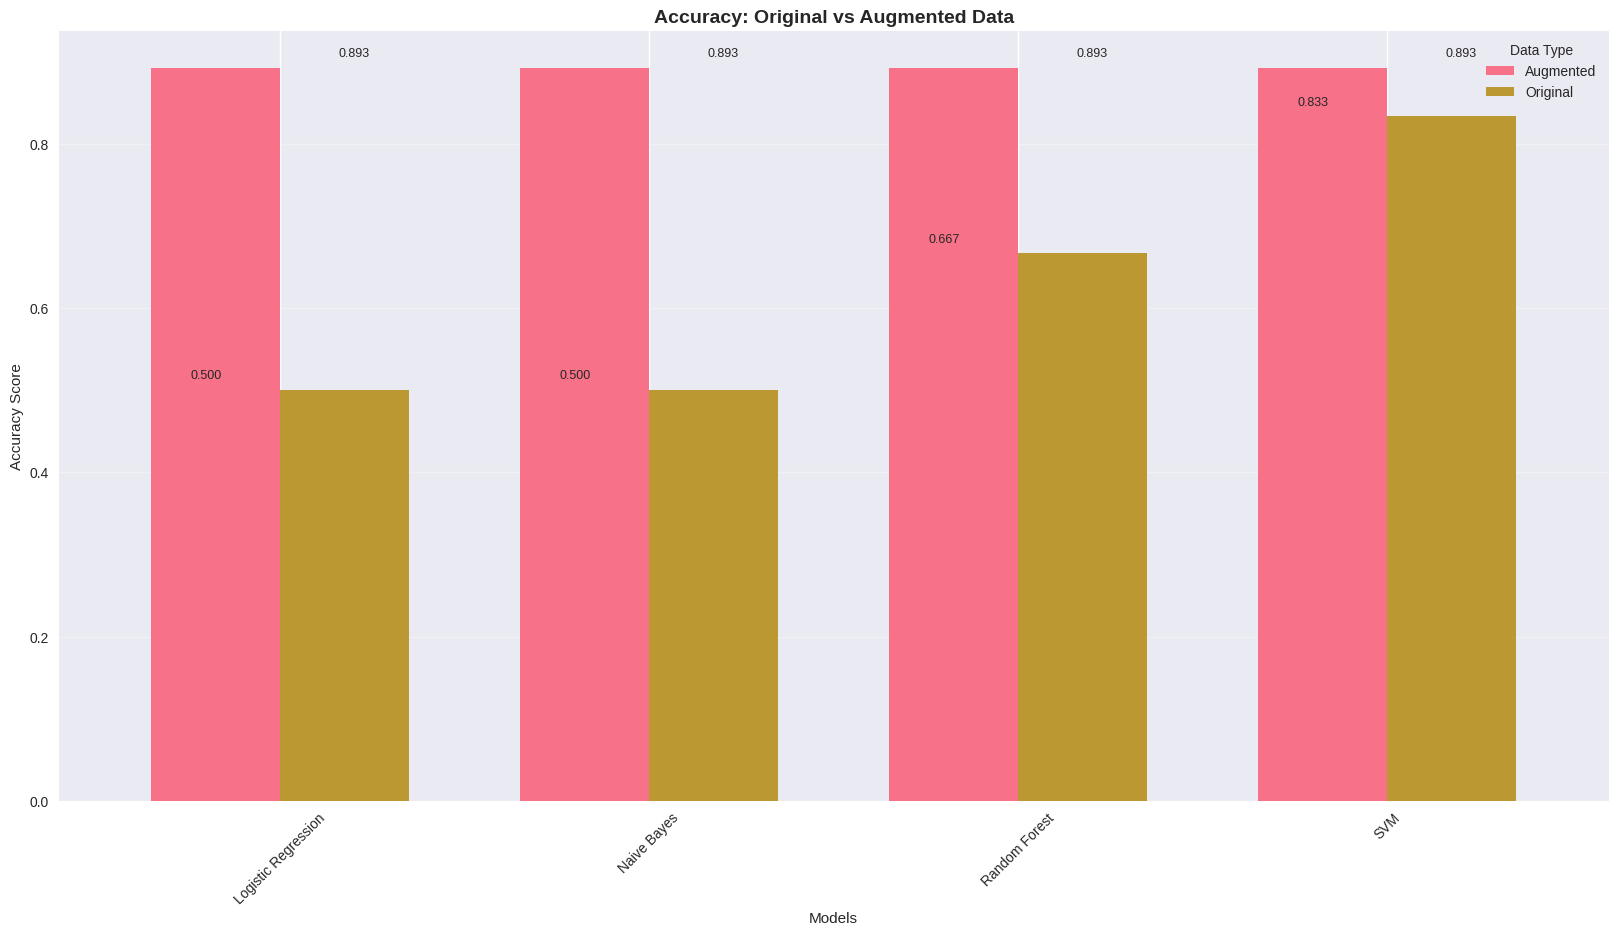

In [ ]:
comparison_df = compare_models_with_and_without_augmentation()

plt.figure(figsize=(20, 10))

accuracy_pivot = comparison_df.pivot(index='model', columns='condition', values='accuracy')
accuracy_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Accuracy: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, model in enumerate(accuracy_pivot.index):
    plt.text(i-0.2, accuracy_pivot.loc[model, 'Original'] + 0.01, 
             f'{accuracy_pivot.loc[model, "Original"]:.3f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(i+0.2, accuracy_pivot.loc[model, 'Augmented'] + 0.01, 
             f'{accuracy_pivot.loc[model, "Augmented"]:.3f}', 
             ha='center', va='bottom', fontsize=9)

In [ ]:
comparison_df.head()

,model,condition,accuracy,precision,recall,f1
0,Naive Bayes,Original,0.500000,0.250000,0.500000,0.333333
1,Naive Bayes,Augmented,0.892857,0.923077,0.928571,0.916522
2,Logistic Regression,Original,0.500000,0.250000,0.500000,0.333333
3,Logistic Regression,Augmented,0.892857,0.923077,0.928571,0.916522
4,SVM,Original,0.833333,0.875000,0.833333,0.828571


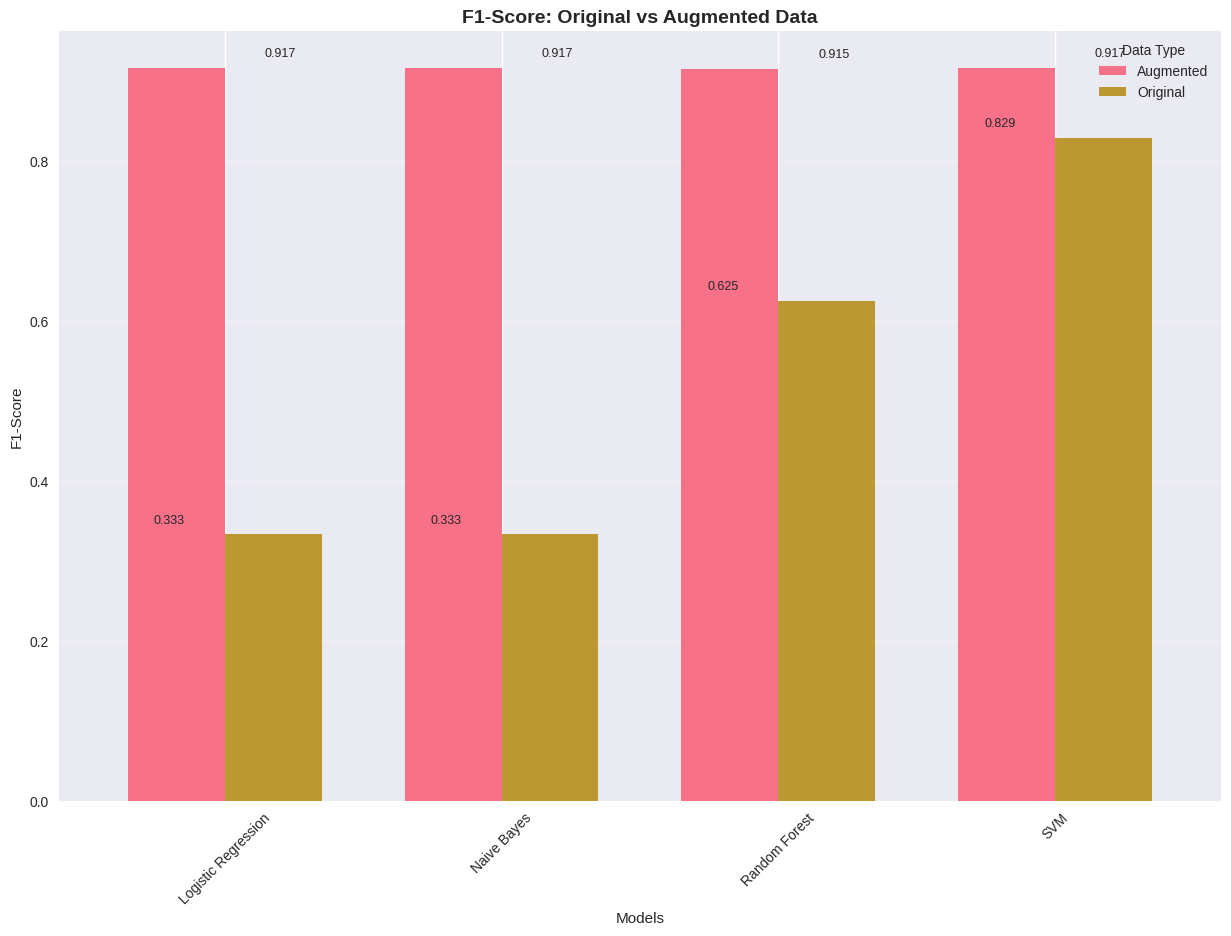

In [ ]:
plt.figure(figsize=(15, 10))
f1_pivot = comparison_df.pivot(index='model', columns='condition', values='f1')
f1_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('F1-Score: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, model in enumerate(f1_pivot.index):
    plt.text(i-0.2, f1_pivot.loc[model, 'Original'] + 0.01, 
             f'{f1_pivot.loc[model, "Original"]:.3f}', 
             ha='center', va='bottom', fontsize=9)
    plt.text(i+0.2, f1_pivot.loc[model, 'Augmented'] + 0.01, 
             f'{f1_pivot.loc[model, "Augmented"]:.3f}', 
             ha='center', va='bottom', fontsize=9)

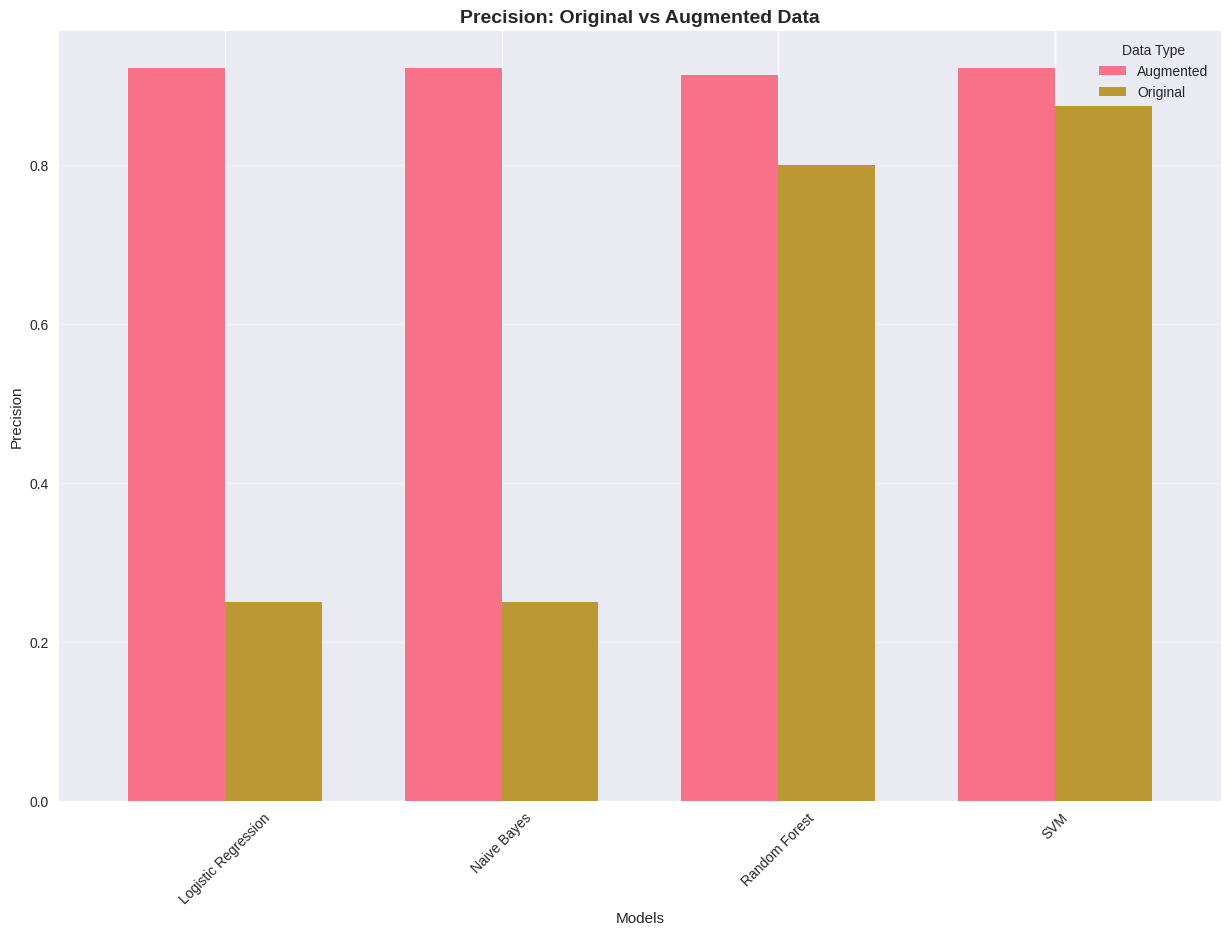

In [ ]:
plt.figure(figsize=(15, 10))
precision_pivot = comparison_df.pivot(index='model', columns='condition', values='precision')
precision_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Precision: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('Precision')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

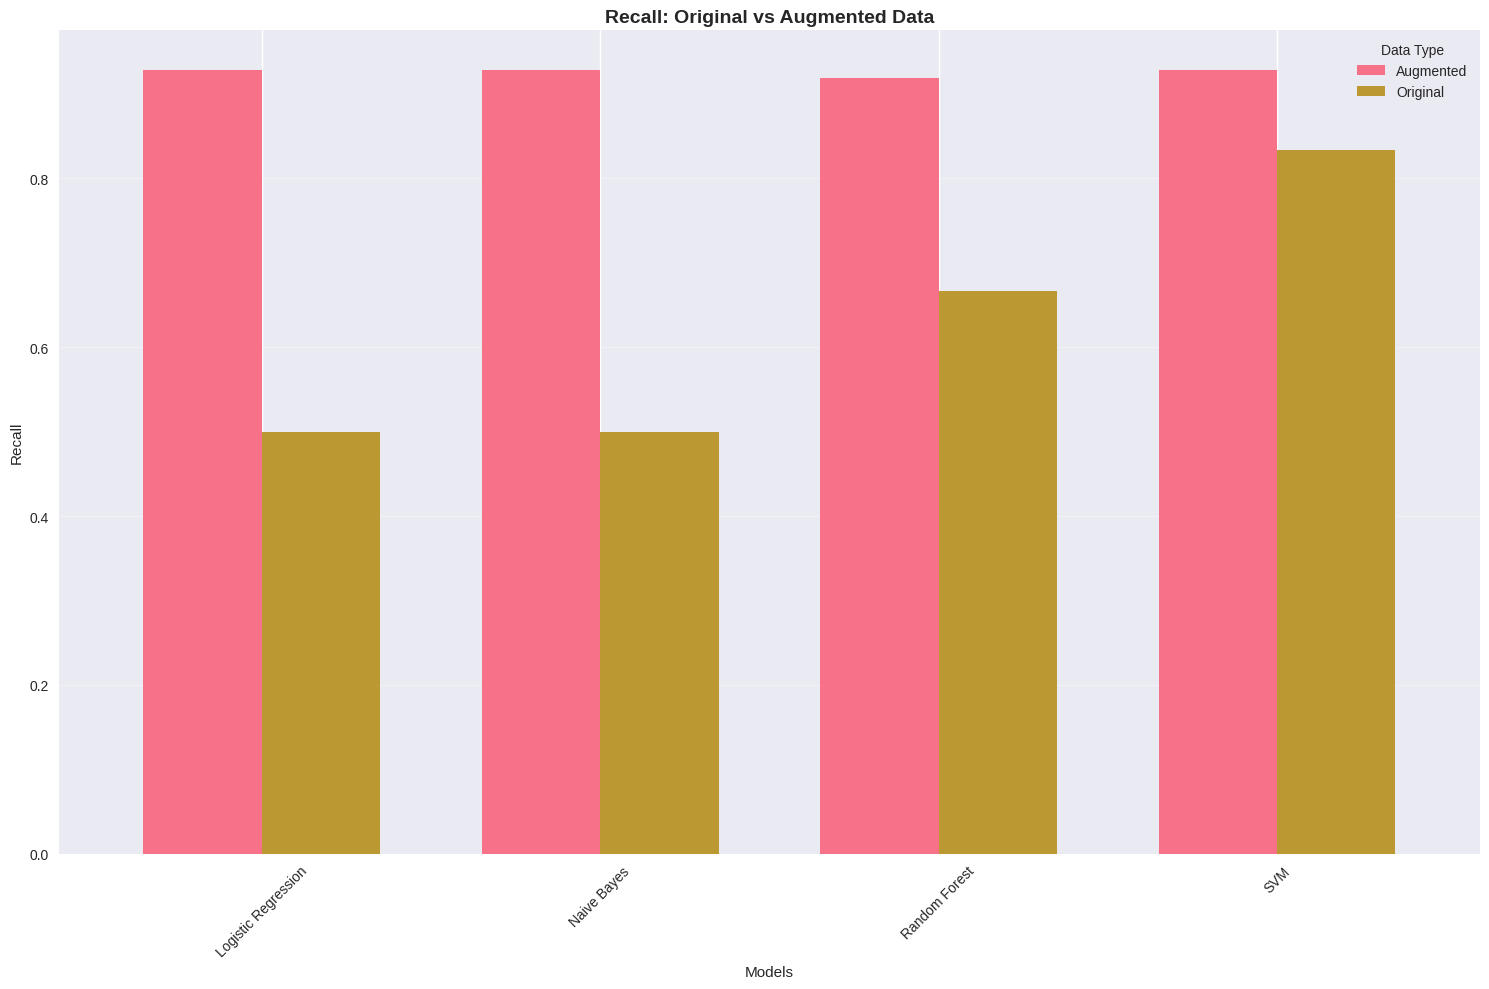

In [ ]:
plt.figure(figsize=(15, 10))
recall_pivot = comparison_df.pivot(index='model', columns='condition', values='recall')
recall_pivot.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Recall: Original vs Augmented Data', fontsize=14, fontweight='bold')
plt.ylabel('Recall')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.legend(title='Data Type')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

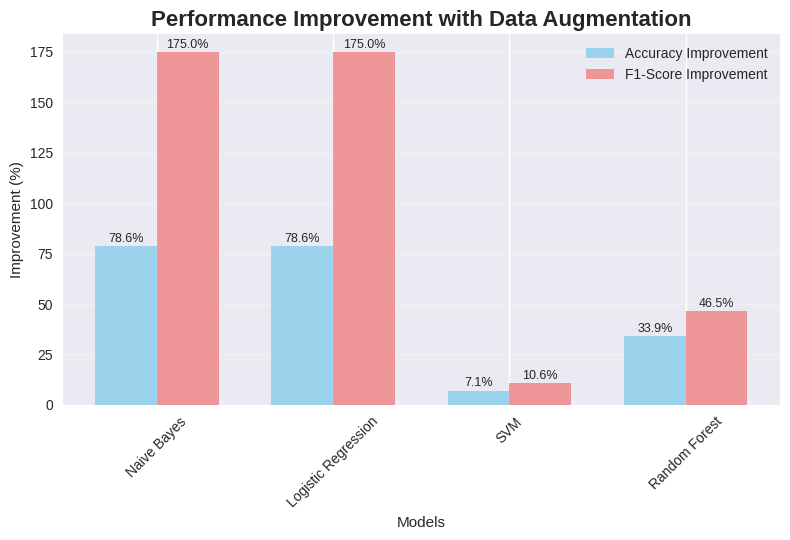

In [ ]:
improvement_data = []
for model in comparison_df['model'].unique():
    orig_acc = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Original')]['accuracy'].iloc[0]
    aug_acc = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Augmented')]['accuracy'].iloc[0]
    
    orig_f1 = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Original')]['f1'].iloc[0]
    aug_f1 = comparison_df[(comparison_df['model'] == model) & (comparison_df['condition'] == 'Augmented')]['f1'].iloc[0]
    
    acc_improvement = ((aug_acc - orig_acc) / orig_acc * 100) if orig_acc > 0 else 0
    f1_improvement = ((aug_f1 - orig_f1) / orig_f1 * 100) if orig_f1 > 0 else 0
    
    improvement_data.append({
        'model': model,
        'accuracy_improvement': acc_improvement,
        'f1_improvement': f1_improvement
    })

improvement_df = pd.DataFrame(improvement_data)

# Plot de melhoria
x = np.arange(len(improvement_df))
width = 0.35

plt.bar(x - width/2, improvement_df['accuracy_improvement'], width, 
        label='Accuracy Improvement', alpha=0.8, color='skyblue')
plt.bar(x + width/2, improvement_df['f1_improvement'], width, 
        label='F1-Score Improvement', alpha=0.8, color='lightcoral')

plt.xlabel('Models')
plt.ylabel('Improvement (%)')
plt.title('Performance Improvement with Data Augmentation', fontsize=16, fontweight='bold')
plt.xticks(x, improvement_df['model'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Adicionar valores nas barras
for i, (acc_imp, f1_imp) in enumerate(zip(improvement_df['accuracy_improvement'], improvement_df['f1_improvement'])):
    plt.text(i - width/2, acc_imp + 0.5, f'{acc_imp:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, f1_imp + 0.5, f'{f1_imp:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

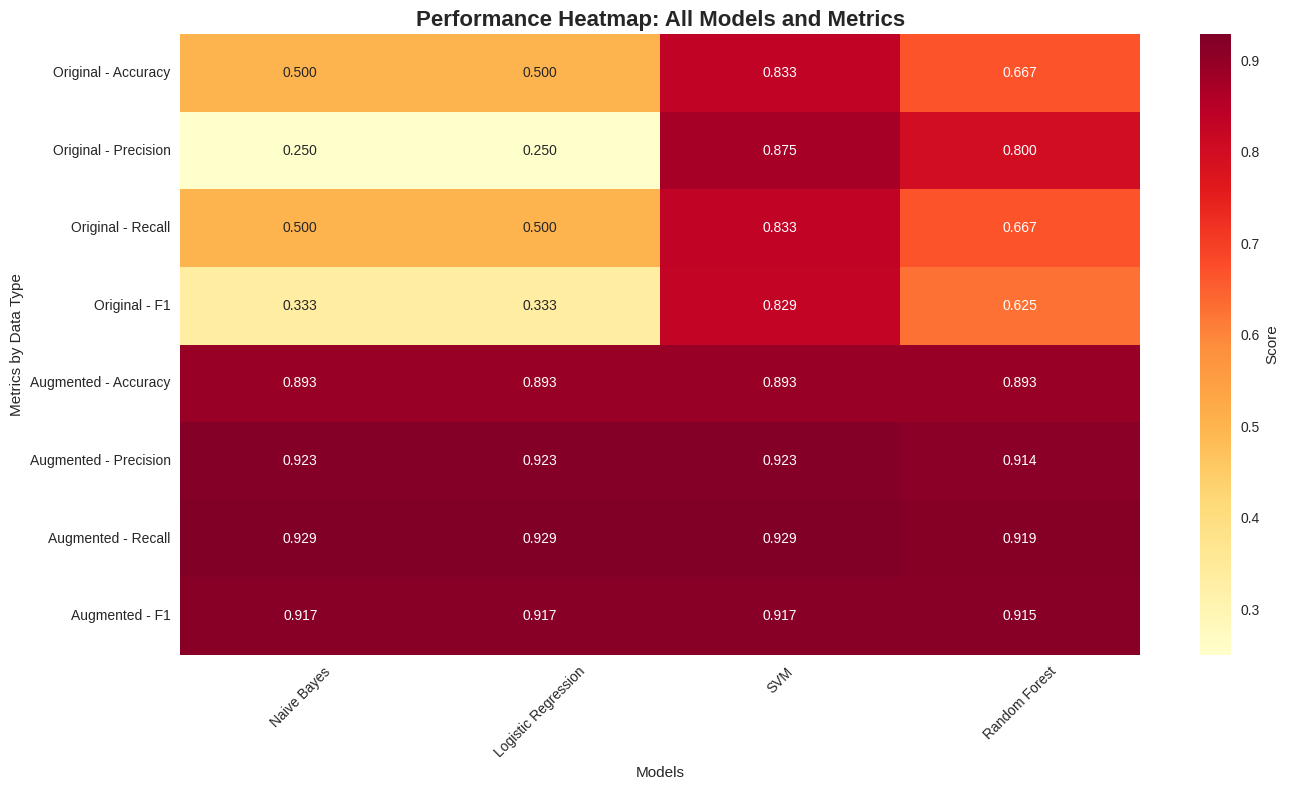

In [ ]:
plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
metrics = ['accuracy', 'precision', 'recall', 'f1']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) & 
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix, 
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True, 
            fmt='.3f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Score'})

plt.title('Performance Heatmap: All Models and Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Metrics by Data Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("\n=== TABELA RESUMO DE PERFORMANCE ===")

summary_table = comparison_df.round(4)
print(summary_table.to_string(index=False))

print(f"Dataset Original: {len(df_original)} amostras")
print(f"Dataset Aumentado: {len(df_augmented)} amostras")
print(f"Aumento: {((len(df_augmented) - len(df_original)) / len(df_original) * 100):.1f}%")

# Calcular média de melhoria
avg_acc_improvement = improvement_df['accuracy_improvement'].mean()
avg_f1_improvement = improvement_df['f1_improvement'].mean()

print(f"  Accuracy: {avg_acc_improvement:+.1f}%")
print(f"  F1-Score: {avg_f1_improvement:+.1f}%")

# Melhor modelo
best_model_orig = comparison_df[comparison_df['condition'] == 'Original'].loc[
    comparison_df[comparison_df['condition'] == 'Original']['accuracy'].idxmax()
]['model']

best_model_aug = comparison_df[comparison_df['condition'] == 'Augmented'].loc[
    comparison_df[comparison_df['condition'] == 'Augmented']['accuracy'].idxmax()
]['model']

print(f"\nMelhor Modelo (Original): {best_model_orig}")
print(f"Melhor Modelo (Augmented): {best_model_aug}")



=== TABELA RESUMO DE PERFORMANCE ===
              model condition  accuracy  precision  recall     f1
        Naive Bayes  Original    0.5000     0.2500  0.5000 0.3333
        Naive Bayes Augmented    0.8929     0.9231  0.9286 0.9165
Logistic Regression  Original    0.5000     0.2500  0.5000 0.3333
Logistic Regression Augmented    0.8929     0.9231  0.9286 0.9165
                SVM  Original    0.8333     0.8750  0.8333 0.8286
                SVM Augmented    0.8929     0.9231  0.9286 0.9165
      Random Forest  Original    0.6667     0.8000  0.6667 0.6250
      Random Forest Augmented    0.8929     0.9138  0.9190 0.9153
Dataset Original: 28 amostras
Dataset Aumentado: 140 amostras
Aumento: 400.0%
  Accuracy: +49.6%
  F1-Score: +101.7%

Melhor Modelo (Original): SVM
Melhor Modelo (Augmented): Naive Bayes


## Testing text generation by Neural Networks

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import random
import os
from collections import Counter

/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
df = pd.read_csv("../CSV/PIBIC - Transcrições - TOC_audio_transcriptions.csv")

df.columns = df.columns.str.strip()

# remove \n from df.columns
df.columns = df.columns.str.replace('\n', '', regex=True)

print(df["Classificação"].unique())

['ÚTIL' 'Transtorno dismorfico corporal' 'EXPERIÊNCIA PESSOAL\n'
 'Espanhol' 'Pessoas Neurodivergentes' 'Repetido' 'EXPERIÊNCIA PESSOAL'
 'Não está relacionado ao TOC' 'Francês ']


In [9]:
# Using one hot encoding
dictionary = dict({
    "experiência pessoal": 1,
    "experiencia pessoal": 1,
    "útil": 2,
    "util": 2,
    "enganoso": 3,
    "outra": 4,
    "outro": 4,
    "inglês": 5,
    "ingles": 5,
    "espanhol": 5,
    "repetido": 5,
    "tod": 5,
    "indisponível": 5,
    "indisponivel": 5,
    "suicídio": 5,
    "suicidio": 5,
    "tdah": 5,
    "não incluso": 5,
    "nao incluso": 5,
})


# Replacing in Classifier column and removing blank spaces in the end
df['Classificação'] = df['Classificação'].str.rstrip()
# Change to lower case
df['Classificação'] = df['Classificação'].str.lower()

df["Classificação"] = df["Classificação"].fillna(5)

# Converting to one hot encoding
df['Classificação'] = df['Classificação'].replace(dictionary)
df = df[~df['Classificação'].apply(lambda x: isinstance(x, str))]

#Remove rows with 4 value
df = df[df['Classificação'] != 5]
df.head()

,ID,Transcription,Tag,Link,Platform,Views,Classificação
0,0,o toque É também um dos coisas mais desafiador...,TOC,https://www.instagram.com/reel/ChqA9jBgGt5/?ig...,Instagram,1103167,2
1,6,a gente conversando sobre Michael Jackson ele ...,TOC,https://www.instagram.com/reel/CovPMQsAj-H/?ig...,Instagram,1259396,2
2,8,o toque nada mais é do que uma ansiedade muito...,TOC,https://www.instagram.com/reel/CoQXDQKg_mF/?ig...,Instagram,1175635,2
4,12,quem tem toque é um sofredor você pode ter cer...,TOC,https://www.instagram.com/reel/CooHQlagmsD/?ig...,Instagram,1237270,1
17,80,toque tem cura com orientação correta não não ...,TOC,https://www.instagram.com/reel/DGvIYpVMot8/?ig...,Instagram,134028,2


In [10]:
print(df['Classificação'].value_counts())

Classificação
2    6
1    2
Name: count, dtype: int64


In [11]:
stop_words = set(stopwords.words('portuguese'))
df['tokenized_words'] = df['Transcription'].apply(lambda x: word_tokenize(x))

df['removed_stopwords'] = df['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df['tokenized_words_joined'] = df['removed_stopwords'].apply(lambda x: ' '.join(x))

In [12]:
texts_by_class = {}
for class_id in df['Classificação'].unique():
    class_texts = df[df['Classificação'] == class_id]['Transcription'].tolist()
    texts_by_class[class_id] = class_texts
    print(f"Classe {class_id}: {len(class_texts)} textos")

Classe 2: 6 textos
Classe 1: 2 textos


In [13]:
# Create more samples for classes with less than 5 samples
for class_id, texts in texts_by_class.items():
    if len(texts) < 5:
        new_texts = []
        while len(new_texts) + len(texts) < 5:
            original_text = random.choice(texts)
            
            augmentation_type = random.choice([
                'back_translate', 
                'synonym_replacement', 
                'random_insertion', 
                'random_swap', 
                'random_deletion', 
                'simple_paraphrase'
            ])
            
            if augmentation_type == 'back_translate':
                augmented_text = back_translate(original_text)
            elif augmentation_type == 'synonym_replacement':
                augmented_text = synonym_replacement(original_text, n_replace=2)
            elif augmentation_type == 'random_insertion':
                augmented_text = random_insertion(original_text, n_insert=1)
            elif augmentation_type == 'random_swap':
                augmented_text = random_swap(original_text, n_swap=1)
            elif augmentation_type == 'random_deletion':
                augmented_text = random_deletion(original_text, p=0.1)
            elif augmentation_type == 'simple_paraphrase':
                augmented_text = simple_paraphrase(original_text)
            
            new_texts.append(augmented_text)
        
        texts_by_class[class_id].extend(new_texts)

/tmp/ipykernel_2047/1991834906.py:18: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  augmented_text = back_translate(original_text)


In [14]:
texts_by_class

{2: ['o toque É também um dos coisas mais desafiadoras o toque de pensamento mais desafiador ainda eu imagino que eu não consigo imaginar como é que parar com o pensamento ela acaba indo para depressão é a consequência por quê Porque leva o cérebro a exaustão que o toque só pensa coisa ruim meu filho por isso que é obsessivo o toque do pensamento não qualquer toque não mas no meu caso era o transtorno preciso compulsivo que eu tinha que fazer aquilo senão o mundo acabar é o é é isso aí ó quando você fala transtorno obsessivo obsessivo é porque você é verdade é verdade se eu falar se eu não fizesse aquilo a vida não teria sentido porque se é uma coisa boa não pode ser pensamento obsessivo obsessivo ele se repete ele é negativo',
  'a gente conversando sobre Michael Jackson ele falou Michael Jackson mais Mania do Fernando toque grave e chegou uma hora que ele bateu ali na Psicose porque o toque muito grave pode evoluir para Psicose o que que é psicose quando a pessoa sai da realidade ela

In [15]:
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
embedding_model = AutoModel.from_pretrained(model_name)

def get_text_embeddings(texts, max_length=128):
    """Converte textos em embeddings usando BERT"""
    embeddings = []
    
    for text in texts:
        # Tokenizar
        inputs = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        
        # Obter embeddings
        with torch.no_grad():
            outputs = embedding_model(**inputs)
            # Usar o [CLS] token como representação do texto
            embedding = outputs.last_hidden_state[:, 0, :].squeeze()
            embeddings.append(embedding.numpy())
    
    return np.array(embeddings)

print("Gerando embeddings...")
embeddings_by_class = {}
for class_id, texts in texts_by_class.items():
    print(f"Processando classe {class_id}...")
    embeddings = get_text_embeddings(texts[:50])  # Limitar para evitar sobrecarga
    embeddings_by_class[class_id] = embeddings
    print(f"  Shape: {embeddings.shape}")

Gerando embeddings...
Processando classe 2...


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


  Shape: (6, 768)
Processando classe 1...
  Shape: (5, 768)


In [16]:
class Generator(nn.Module):
    """Gerador da GAN para criar embeddings sintéticos"""
    def __init__(self, noise_dim=300, embedding_dim=768, hidden_dim=512):
        super(Generator, self).__init__()
        
        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada 2
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada 3
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada de saída
            nn.Linear(hidden_dim, embedding_dim),
            nn.Tanh()  # Normalizar saída
        )
    
    def forward(self, noise):
        return self.model(noise)

class Discriminator(nn.Module):
    """Discriminador da GAN para distinguir embeddings reais de sintéticos"""
    def __init__(self, embedding_dim=768, hidden_dim=512):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(embedding_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Camada 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Camada 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Camada de saída
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, embedding):
        return self.model(embedding)

In [17]:
def train_gan_for_class(embeddings, epochs=100, batch_size=16, noise_dim=100):
    """Treina uma GAN para uma classe específica"""
    
    # Verificar se temos dados suficientes
    if len(embeddings) < batch_size:
        print(f"Poucos dados ({len(embeddings)}), ajustando batch_size para {len(embeddings)}")
        batch_size = len(embeddings)
    
    # Inicializar modelos
    embedding_dim = embeddings.shape[1]
    generator = Generator(noise_dim, embedding_dim)
    discriminator = Discriminator(embedding_dim)
    
    # Otimizadores
    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    
    # Função de perda
    criterion = nn.BCELoss()
    
    # Converter para tensor
    real_embeddings = torch.FloatTensor(embeddings)
    
    # Listas para armazenar perdas
    g_losses = []
    d_losses = []
    
    print(f"Iniciando treinamento com {len(embeddings)} amostras...")
    
    for epoch in range(epochs):
        # Embaralhar dados
        indices = torch.randperm(len(real_embeddings))
        
        epoch_g_loss = 0
        epoch_d_loss = 0
        num_batches = 0
        
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            real_batch = real_embeddings[batch_indices]
            batch_len = len(real_batch)
            
            # Labels
            real_labels = torch.ones(batch_len, 1)
            fake_labels = torch.zeros(batch_len, 1)
            
            # ===== TREINAR DISCRIMINADOR =====
            d_optimizer.zero_grad()
            
            # Discriminador com dados reais
            d_real = discriminator(real_batch)
            d_real_loss = criterion(d_real, real_labels)
            
            # Discriminador com dados sintéticos
            noise = torch.randn(batch_len, noise_dim)
            fake_batch = generator(noise)
            d_fake = discriminator(fake_batch.detach())
            d_fake_loss = criterion(d_fake, fake_labels)
            
            # Total discriminador
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()
            
            # ===== TREINAR GERADOR =====
            g_optimizer.zero_grad()
            
            # Gerador tenta enganar discriminador
            noise = torch.randn(batch_len, noise_dim)
            fake_batch = generator(noise)
            d_fake = discriminator(fake_batch)
            g_loss = criterion(d_fake, real_labels)  # Quer que seja classificado como real
            
            g_loss.backward()
            g_optimizer.step()
            
            # Acumular perdas
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1
        
        # Média das perdas da época
        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches
        
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: G_Loss = {avg_g_loss:.4f}, D_Loss = {avg_d_loss:.4f}")
    
    return generator, discriminator, g_losses, d_losses

In [18]:
generators = {}
discriminators = {}
training_histories = {}

for class_id, embeddings in embeddings_by_class.items():
    print(f"\n--- TREINANDO GAN PARA CLASSE {class_id} ---")

    
    try:
        generator, discriminator, g_losses, d_losses = train_gan_for_class(
            embeddings, epochs=50, batch_size=50, noise_dim=300
        )
        
        generators[class_id] = generator
        discriminators[class_id] = discriminator
        training_histories[class_id] = {'g_losses': g_losses, 'd_losses': d_losses}
        
        print(f"✓ GAN treinada para classe {class_id}")
        
    except Exception as e:
        print(f"Erro ao treinar GAN para classe {class_id}: {e}")


--- TREINANDO GAN PARA CLASSE 2 ---
Poucos dados (6), ajustando batch_size para 6
Iniciando treinamento com 6 amostras...
Epoch 0: G_Loss = 0.7247, D_Loss = 1.3564
Epoch 20: G_Loss = 0.6938, D_Loss = 1.1926
Epoch 40: G_Loss = 0.9620, D_Loss = 0.9381
✓ GAN treinada para classe 2

--- TREINANDO GAN PARA CLASSE 1 ---
Poucos dados (5), ajustando batch_size para 5
Iniciando treinamento com 5 amostras...
Epoch 0: G_Loss = 0.7414, D_Loss = 1.3878
Epoch 20: G_Loss = 0.7041, D_Loss = 1.2174
Epoch 40: G_Loss = 0.9740, D_Loss = 0.8824
✓ GAN treinada para classe 1


In [19]:
def generate_synthetic_embeddings(generator, num_samples=50, noise_dim=100):
    """Gera embeddings sintéticos usando o gerador treinado"""
    generator.eval()
    
    with torch.no_grad():
        noise = torch.randn(num_samples, noise_dim)
        synthetic_embeddings = generator(noise)
    
    return synthetic_embeddings.numpy()

In [20]:
synthetic_embeddings_by_class = {}

for class_id, generator in generators.items():
    print(f"Gerando embeddings sintéticos para classe {class_id}...")
    
    # Gerar mais amostras para classes com poucos dados
    original_count = len(embeddings_by_class[class_id])
    target_count = max(100, original_count * 3)  # Pelo menos 100 ou 3x o original
    
    synthetic_embeddings = generate_synthetic_embeddings(
        generator, num_samples=target_count, noise_dim=300
    )
    
    synthetic_embeddings_by_class[class_id] = synthetic_embeddings
    
    print(f"  Originais: {original_count}, Sintéticos: {len(synthetic_embeddings)}")

Gerando embeddings sintéticos para classe 2...
  Originais: 6, Sintéticos: 100
Gerando embeddings sintéticos para classe 1...
  Originais: 5, Sintéticos: 100


In [23]:
def embedding_to_text_simple(embedding, original_texts, similarity_threshold=0.7):
    """
    Converte embedding sintético em texto usando similaridade com textos originais.
    Esta é uma abordagem simplificada - para produção, usaria modelos mais sofisticados.
    """
    # Calcular similaridade com embeddings originais
    original_embeddings = get_text_embeddings(original_texts[:20])  # Limitar para performance
    
    # Calcular similaridade coseno
    similarities = []
    for orig_emb in original_embeddings:
        similarity = np.dot(embedding, orig_emb) / (np.linalg.norm(embedding) * np.linalg.norm(orig_emb))
        similarities.append(similarity)
    
    # Encontrar texto mais similar
    most_similar_idx = np.argmax(similarities)
    most_similar_text = original_texts[most_similar_idx]
    max_similarity = similarities[most_similar_idx]
    
    # Se similaridade é muito baixa, criar variação do texto mais similar
    if max_similarity < similarity_threshold:
        # Aplicar técnicas simples de variação
        words = most_similar_text.split()
        
        # Técnicas de variação
        if len(words) > 3:
            # Trocar ordem de algumas palavras
            if random.random() > 0.5:
                idx1, idx2 = random.sample(range(len(words)), 2)
                words[idx1], words[idx2] = words[idx2], words[idx1]
            
            # Adicionar conectivos
            if random.random() > 0.5:
                connectors = ["então", "mas", "porém", "além disso", "na verdade"]
                connector = random.choice(connectors)
                words.insert(random.randint(0, len(words)), connector)
        
        return ' '.join(words)
    
    return most_similar_text

In [24]:
synthetic_texts_by_class = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando classe {class_id}...")
    
    original_texts = texts_by_class[class_id]
    synthetic_texts = []
    
    # Processar em lotes menores para evitar sobrecarga
    batch_size = 10
    for i in range(0, len(synthetic_embeddings), batch_size):
        batch_embeddings = synthetic_embeddings[i:i+batch_size]
        
        for embedding in batch_embeddings:
            try:
                synthetic_text = embedding_to_text_simple(embedding, original_texts)
                synthetic_texts.append(synthetic_text)
            except Exception as e:
                print(f"Erro ao converter embedding: {e}")
                # Usar texto original como fallback
                synthetic_texts.append(random.choice(original_texts))
        
        if i % 50 == 0:
            print(f"  Processados {min(i+batch_size, len(synthetic_embeddings))}/{len(synthetic_embeddings)}")
    
    synthetic_texts_by_class[class_id] = synthetic_texts
    print(f"  Gerados {len(synthetic_texts)} textos sintéticos")


Processando classe 2...
  Processados 10/100
  Processados 60/100
  Gerados 100 textos sintéticos
Processando classe 1...
  Processados 10/100
  Processados 60/100
  Gerados 100 textos sintéticos


In [25]:
gan_augmented_data = []

# Adicionar dados originais
for _, row in df.iterrows():
    gan_augmented_data.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

# Adicionar dados sintéticos das GANs
for class_id, synthetic_texts in synthetic_texts_by_class.items():
    for text in synthetic_texts:
        gan_augmented_data.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

# Criar DataFrame
df_gan_augmented = pd.DataFrame(gan_augmented_data)

print(f"Dataset original: {len(df)} amostras")
print(f"Dataset aumentado com GANs: {len(df_gan_augmented)} amostras")
print(f"Aumento: {((len(df_gan_augmented) - len(df)) / len(df) * 100):.1f}%")

print("\nDistribuição das classes no dataset GAN-aumentado:")
print(df_gan_augmented['Classificação'].value_counts())

Dataset original: 8 amostras
Dataset aumentado com GANs: 208 amostras
Aumento: 2500.0%

Distribuição das classes no dataset GAN-aumentado:
Classificação
2    106
1    102
Name: count, dtype: int64


In [27]:
for class_id in df_gan_augmented['Classificação'].unique():
    print(f"\nClasse {class_id}:")
    
    # Original
    original_sample = df_gan_augmented[
        (df_gan_augmented['Classificação'] == class_id) & 
        (df_gan_augmented['augmentation_type'] == 'original')
    ]['Transcription'].iloc[0]
    print(f"Original: {original_sample[:100]}...")
    
    # GAN
    gan_samples = df_gan_augmented[
        (df_gan_augmented['Classificação'] == class_id) & 
        (df_gan_augmented['augmentation_type'] == 'gan_synthetic')
    ]
    
    if not gan_samples.empty:
        gan_sample = gan_samples['Transcription'].iloc[0]
        print(f"GAN: {gan_sample[:100]}...")


Classe 2:
Original: o toque É também um dos coisas mais desafiadoras o toque de pensamento mais desafiador ainda eu imag...
GAN: toque é um transtorno de ansiedade mas muito muito grave claro que você tem desde o traço toque são ...

Classe 1:
Original: quem tem toque é um sofredor você pode ter certeza não é brincadeira não sei É mesmo é verdade eu se...
GAN: você quer para o filha da puta do toque quem quer que seja que tenha inventado esse diagnóstico toqu...


### Plots

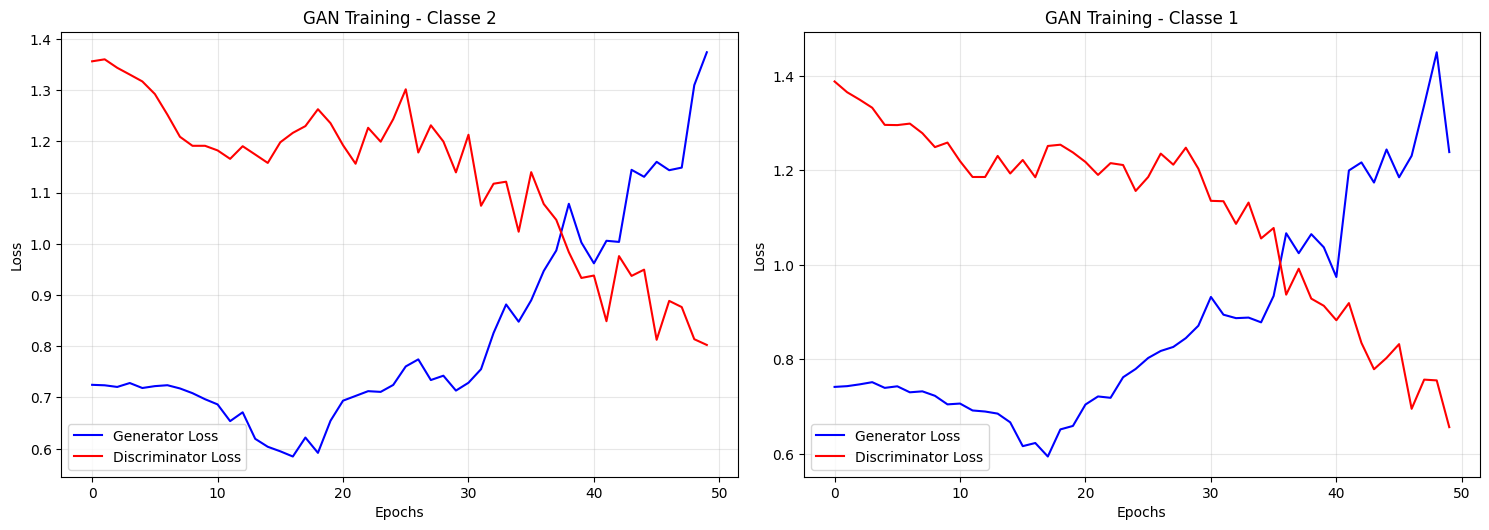

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break
    
    ax = axes[plot_idx]
    
    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')
    
    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plot_idx += 1

# Remover subplots não utilizados
for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [29]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import StratifiedKFold

# Processar dataset GAN-aumentado
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("portuguese"))

df_gan_augmented["tokenized_words"] = df_gan_augmented["Transcription"].apply(
    lambda x: word_tokenize(str(x))
)
df_gan_augmented["removed_stopwords"] = df_gan_augmented["tokenized_words"].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_gan_augmented["tokenized_words_joined"] = df_gan_augmented[
    "removed_stopwords"
].apply(lambda x: " ".join(x))


def test_model_performance_gan(data, title, k=5):
    """Testa performance do modelo com dados GAN-aumentados"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")

    # Vetorização
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=2)
    X = vectorizer.fit_transform(data["tokenized_words_joined"])
    y = data["Classificação"].astype(int)

    # Modelos
    models = {
        "Naive Bayes": MultinomialNB(alpha=70.0),
        "Logistic Regression": LogisticRegression(
            penalty="l2", C=0.1, max_iter=1000, random_state=42
        ),
        "SVM": SVC(kernel="linear", C=0.1, class_weight="balanced", random_state=42),
        "Random Forest": RandomForestClassifier(
            n_estimators=75,
            max_depth= 15,
            class_weight="balanced",
            max_features="sqrt",
            min_samples_split=10,
            min_samples_leaf=8,
            random_state=42,
        ),
    }

    results = {
        name: {"accuracy": [], "f1": [], "precision": [], "recall": []}
        for name in models
    }

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            results[model_name]["accuracy"].append(accuracy_score(y_val, y_pred))
            results[model_name]["f1"].append(f1_score(y_val, y_pred, average="macro"))
            results[model_name]["precision"].append(
                precision_score(y_val, y_pred, average="macro")
            )
            results[model_name]["recall"].append(
                recall_score(y_val, y_pred, average="macro")
            )

    # Mostrar resultados médios
    for model_name in models:
        print(f"{model_name}:")
        print(f"  Accuracy: {np.max(results[model_name]['accuracy']):.4f}")
        print(f"  F1-Score: {np.max(results[model_name]['f1']):.4f}")
        print(f"  Precision: {np.max(results[model_name]['precision']):.4f}")
        print(f"  Recall: {np.max(results[model_name]['recall']):.4f}")

    return results

In [30]:
df.head()

,ID,Transcription,Tag,Link,Platform,Views,Classificação,tokenized_words,removed_stopwords,tokenized_words_joined
0,0,o toque É também um dos coisas mais desafiador...,TOC,https://www.instagram.com/reel/ChqA9jBgGt5/?ig...,Instagram,1103167,2,"[o, toque, É, também, um, dos, coisas, mais, d...","[toque, coisas, desafiadoras, toque, pensament...",toque coisas desafiadoras toque pensamento des...
1,6,a gente conversando sobre Michael Jackson ele ...,TOC,https://www.instagram.com/reel/CovPMQsAj-H/?ig...,Instagram,1259396,2,"[a, gente, conversando, sobre, Michael, Jackso...","[gente, conversando, sobre, Michael, Jackson, ...",gente conversando sobre Michael Jackson falou ...
2,8,o toque nada mais é do que uma ansiedade muito...,TOC,https://www.instagram.com/reel/CoQXDQKg_mF/?ig...,Instagram,1175635,2,"[o, toque, nada, mais, é, do, que, uma, ansied...","[toque, nada, ansiedade, grande, momentos, toq...",toque nada ansiedade grande momentos toque toq...
4,12,quem tem toque é um sofredor você pode ter cer...,TOC,https://www.instagram.com/reel/CooHQlagmsD/?ig...,Instagram,1237270,1,"[quem, tem, toque, é, um, sofredor, você, pode...","[toque, sofredor, pode, ter, certeza, brincade...",toque sofredor pode ter certeza brincadeira se...
17,80,toque tem cura com orientação correta não não ...,TOC,https://www.instagram.com/reel/DGvIYpVMot8/?ig...,Instagram,134028,2,"[toque, tem, cura, com, orientação, correta, n...","[toque, cura, orientação, correta, cura, toque...",toque cura orientação correta cura toque cura ...


In [31]:
df_original_processed = df.copy()
df_original_processed['tokenized_words'] = df_original_processed['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_original_processed['removed_stopwords'] = df_original_processed['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original_processed['tokenized_words_joined'] = df_original_processed['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

results_original_gan = test_model_performance_gan(df_original_processed, "DADOS ORIGINAIS")
results_gan_augmented = test_model_performance_gan(df_gan_augmented, "DADOS GAN-AUMENTADOS")


=== DADOS ORIGINAIS ===
Tamanho do dataset: 8


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/Documents/UFAL/PIBIC

Naive Bayes:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
Logistic Regression:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
SVM:
  Accuracy: 0.5000
  F1-Score: 0.3333
  Precision: 0.5000
  Recall: 0.5000
Random Forest:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000

=== DADOS GAN-AUMENTADOS ===
Tamanho do dataset: 208
Naive Bayes:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
Logistic Regression:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
SVM:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
Random Forest:
  Accuracy: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000


In [32]:
comparison_data = []
for model_name in results_original_gan.keys():
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        original_val = max(results_original_gan[model_name][metric])  # Maior valor
        gan_val = max(results_gan_augmented[model_name][metric])  # Maior valor
        improvement = ((gan_val - original_val) / original_val * 100) if original_val > 0 else 0

        comparison_data.append({
            'Model': model_name,
            'Metric': metric,
            'Original': original_val,
            'GAN_Augmented': gan_val,
            'Improvement_%': improvement
        })

comparison_df_gan = pd.DataFrame(comparison_data)

In [33]:
print(comparison_df_gan.round(4).to_string(index=False))

              Model    Metric  Original  GAN_Augmented  Improvement_%
        Naive Bayes  accuracy    1.0000            1.0            0.0
        Naive Bayes        f1    1.0000            1.0            0.0
        Naive Bayes precision    1.0000            1.0            0.0
        Naive Bayes    recall    1.0000            1.0            0.0
Logistic Regression  accuracy    1.0000            1.0            0.0
Logistic Regression        f1    1.0000            1.0            0.0
Logistic Regression precision    1.0000            1.0            0.0
Logistic Regression    recall    1.0000            1.0            0.0
                SVM  accuracy    0.5000            1.0          100.0
                SVM        f1    0.3333            1.0          200.0
                SVM precision    0.5000            1.0          100.0
                SVM    recall    0.5000            1.0          100.0
      Random Forest  accuracy    1.0000            1.0            0.0
      Random Forest 

In [34]:
def test_dummy_model_performance(data, title):
    """Testa performance do modelo dummy com os dados fornecidos"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")
    
    # Preparar dados
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')
    
    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Modelo Dummy
    model = DummyClassifier(strategy='most_frequent')
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_val)
    
    # Métricas
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred, average='macro'):.4f}")
    
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred, average='macro'),
        'precision': precision_score(y_val, y_pred, average='macro'),
        'recall': recall_score(y_val, y_pred, average='macro')
    }

df_original = df.copy()
# Testar com dados originais usando modelo dummy
results_dummy_original = test_dummy_model_performance(df_original, "DADOS ORIGINAIS - Modelo Dummy")
# Testar com dados aumentados usando modelo dummy
results_dummy_gan_augmented = test_dummy_model_performance(df_gan_augmented, "DADOS GAN AUMENTADOS - Modelo Dummy")
print("Métrica\t\tOriginal Dummy\tAumentado Dummy")
print("-" * 50)
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    original_val = results_dummy_original[metric]
    augmented_val = results_dummy_gan_augmented[metric]
    
    print(f"{metric.capitalize()}\t\t{original_val:.4f}\t\t{augmented_val:.4f}")


=== DADOS ORIGINAIS - Modelo Dummy ===
Tamanho do dataset: 8
Accuracy: 1.0000
F1-Score: 1.0000
Precision: 1.0000
Recall: 1.0000

=== DADOS GAN AUMENTADOS - Modelo Dummy ===
Tamanho do dataset: 208
Accuracy: 0.4762
F1-Score: 0.3226
Precision: 0.2381
Recall: 0.5000
Métrica		Original Dummy	Aumentado Dummy
--------------------------------------------------
Accuracy		1.0000		0.4762
F1		1.0000		0.3226
Precision		1.0000		0.2381
Recall		1.0000		0.5000


/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabriel/Documents/UFAL/PIBIC/MindVid_Research/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


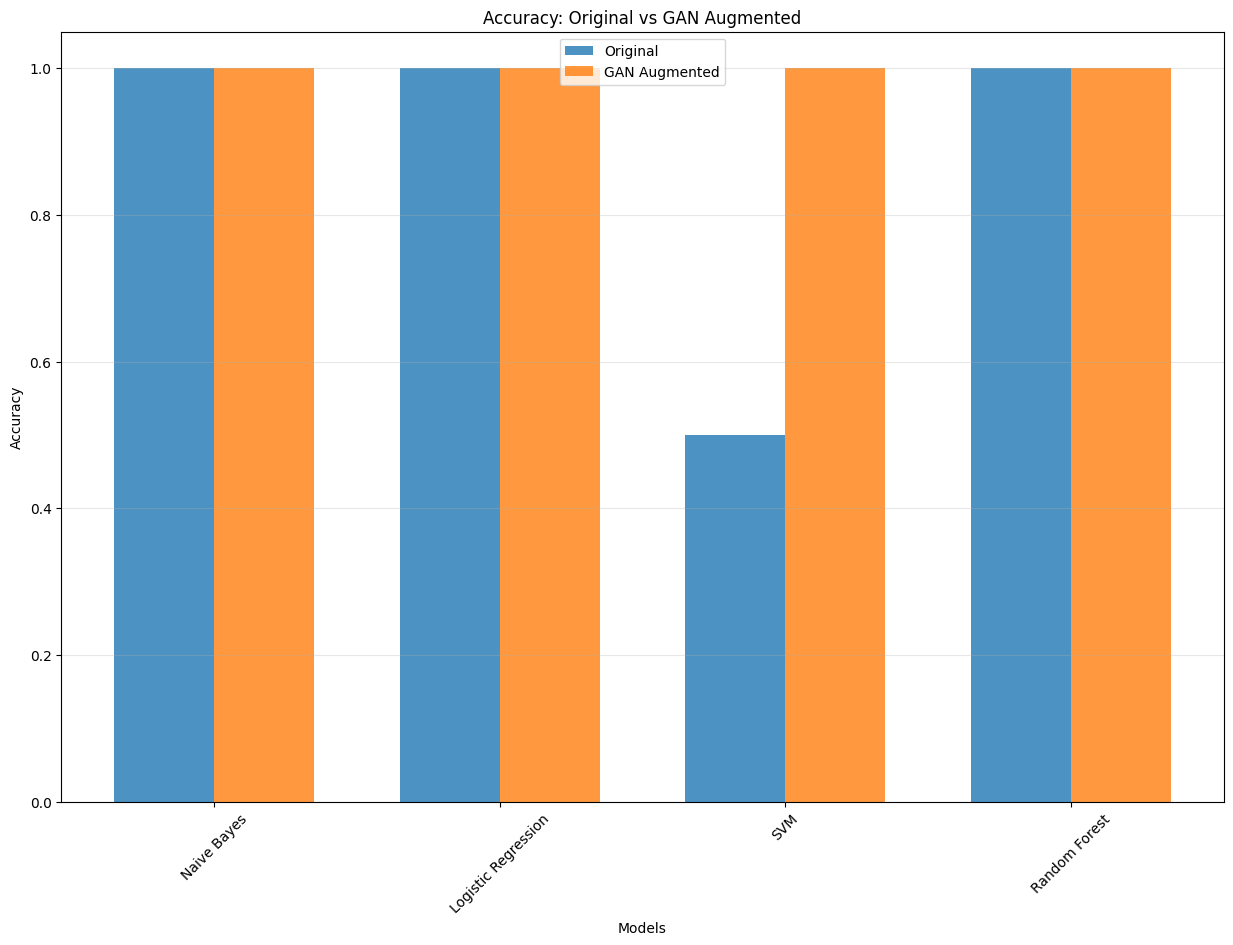

In [35]:
plt.figure(figsize=(15, 10))
models = list(results_original_gan.keys())
original_acc = [max(results_original_gan[m]['accuracy']) for m in models]
gan_acc = [max(results_gan_augmented[m]['accuracy']) for m in models]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, original_acc, width, label='Original', alpha=0.8)
plt.bar(x + width/2, gan_acc, width, label='GAN Augmented', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy: Original vs GAN Augmented')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

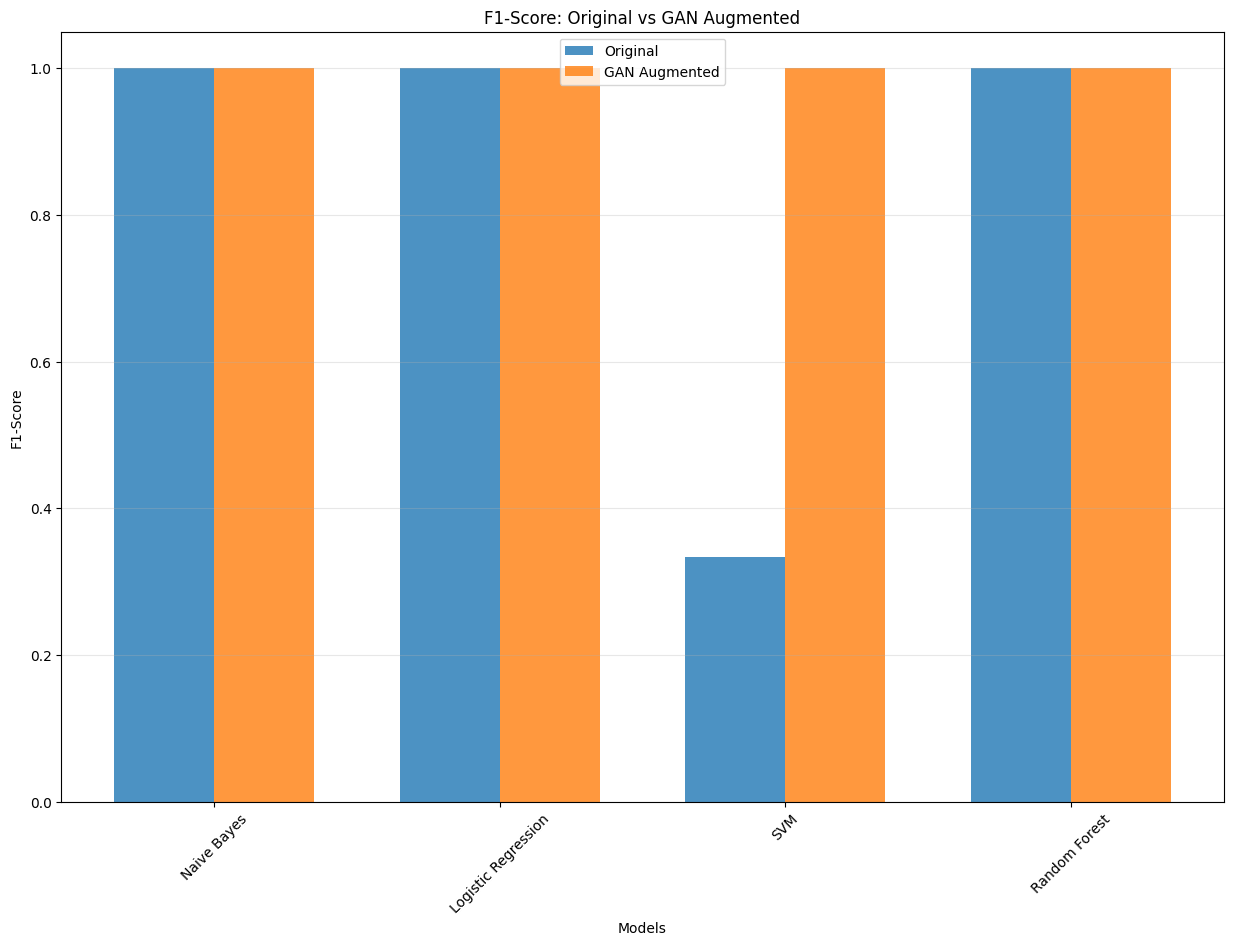

In [36]:
plt.figure(figsize=(15, 10))
original_f1 = [max(results_original_gan[m]['f1']) for m in models]
gan_f1 = [max(results_gan_augmented[m]['f1']) for m in models]

plt.bar(x - width/2, original_f1, width, label='Original', alpha=0.8)
plt.bar(x + width/2, gan_f1, width, label='GAN Augmented', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('F1-Score')
plt.title('F1-Score: Original vs GAN Augmented')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

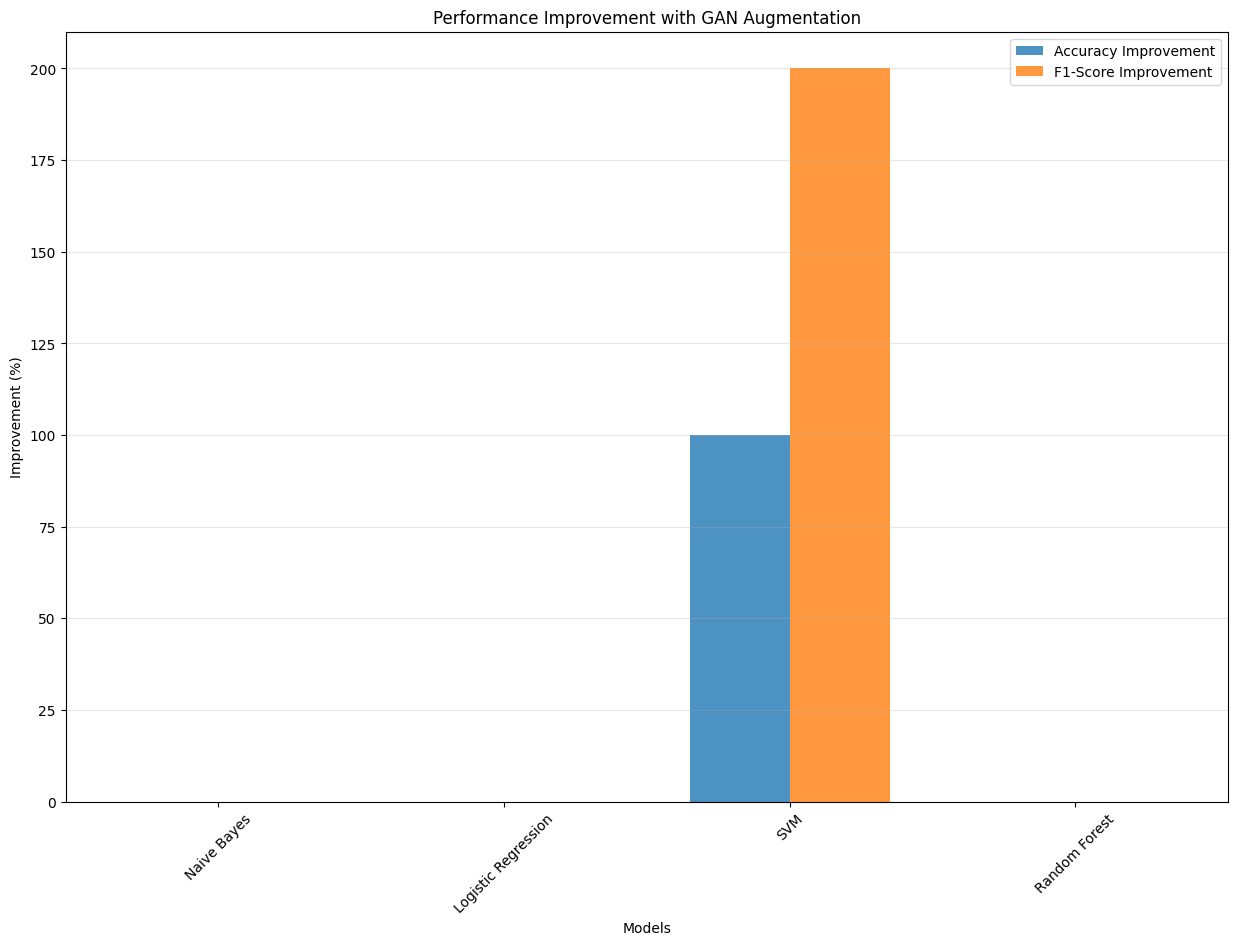

In [37]:
plt.figure(figsize=(15, 10))
acc_improvements = [((gan_acc[i] - original_acc[i]) / original_acc[i] * 100) if original_acc[i] > 0 else 0 for i in range(len(models))]
f1_improvements = [((gan_f1[i] - original_f1[i]) / original_f1[i] * 100) if original_f1[i] > 0 else 0 for i in range(len(models))]

plt.bar(x - width/2, acc_improvements, width, label='Accuracy Improvement', alpha=0.8)
plt.bar(x + width/2, f1_improvements, width, label='F1-Score Improvement', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Improvement (%)')
plt.title('Performance Improvement with GAN Augmentation')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)


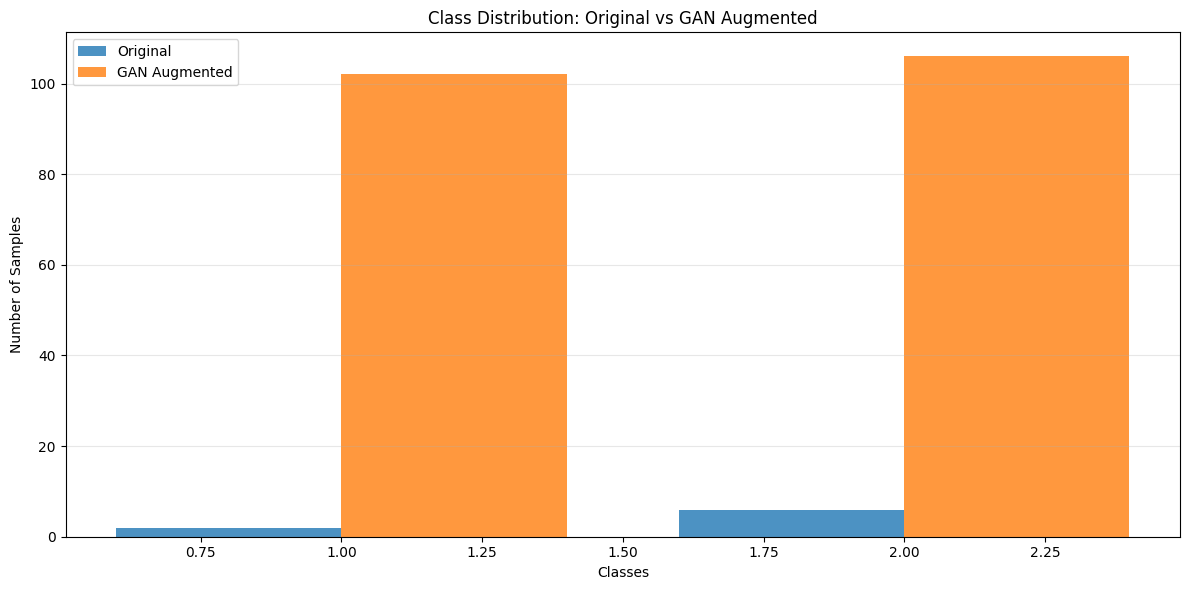

In [38]:
plt.figure(figsize=(12, 6))
original_dist = df['Classificação'].value_counts().sort_index()
gan_dist = df_gan_augmented['Classificação'].value_counts().sort_index()

classes = original_dist.index
plt.bar(classes - 0.2, original_dist.values, 0.4, label='Original', alpha=0.8)
plt.bar(classes + 0.2, gan_dist.values, 0.4, label='GAN Augmented', alpha=0.8)

plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.title('Class Distribution: Original vs GAN Augmented')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

In [39]:
df_gan_augmented.to_csv(f"../CSV/data_{df['Tag'].iloc[0]}_gan_augmented.csv", index=False)

In [40]:
heatmap_data = []
model_labels = []

# Adicionar dados originais
for model in models:
    row = []
    for metric in ["accuracy", "f1", "precision", "recall"]:
        row.append(max(results_original_gan[model][metric]))
    heatmap_data.append(row)
    model_labels.append(f"{model} (Original)")

# Adicionar dados GAN-aumentados
for model in models:
    row = []
    for metric in ["accuracy", "f1", "precision", "recall"]:
        row.append(max(results_gan_augmented[model][metric]))
    heatmap_data.append(row)
    model_labels.append(f"{model} (GAN)")

# Criar DataFrame para o heatmap
heatmap_df = pd.DataFrame(
    heatmap_data,
    index=model_labels,
    columns=["Accuracy", "F1-Score", "Precision", "Recall"],
)

In [41]:
heatmap_df.head()

,Accuracy,F1-Score,Precision,Recall
Naive Bayes (Original),1.0,1.000000,1.0,1.0
Logistic Regression (Original),1.0,1.000000,1.0,1.0
SVM (Original),0.5,0.333333,0.5,0.5
Random Forest (Original),1.0,1.000000,1.0,1.0
Naive Bayes (GAN),1.0,1.000000,1.0,1.0


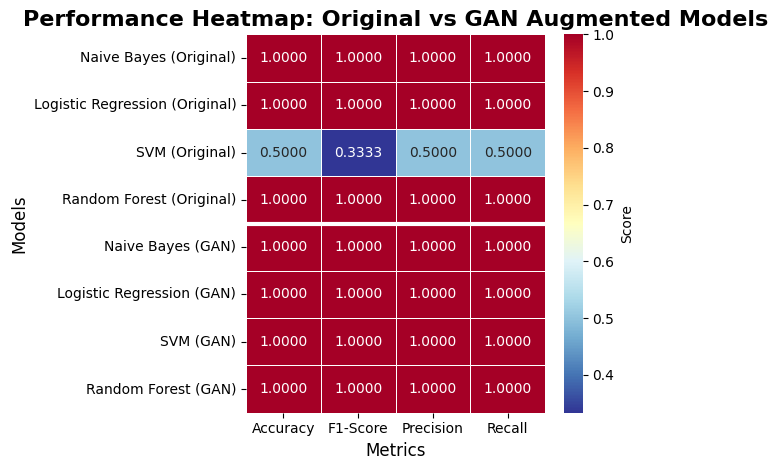

In [42]:
sns.heatmap(
    heatmap_df, 
    annot=True, 
    fmt='.4f', 
    cmap='RdYlBu_r',
    cbar_kws={'label': 'Score'},
    linewidths=0.5,
    square=False
)

plt.title('Performance Heatmap: Original vs GAN Augmented Models', fontsize=16, fontweight='bold')
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

ax = plt.gca()
ax.axhline(y=len(models), color='white', linewidth=3)

plt.tight_layout()
plt.show()

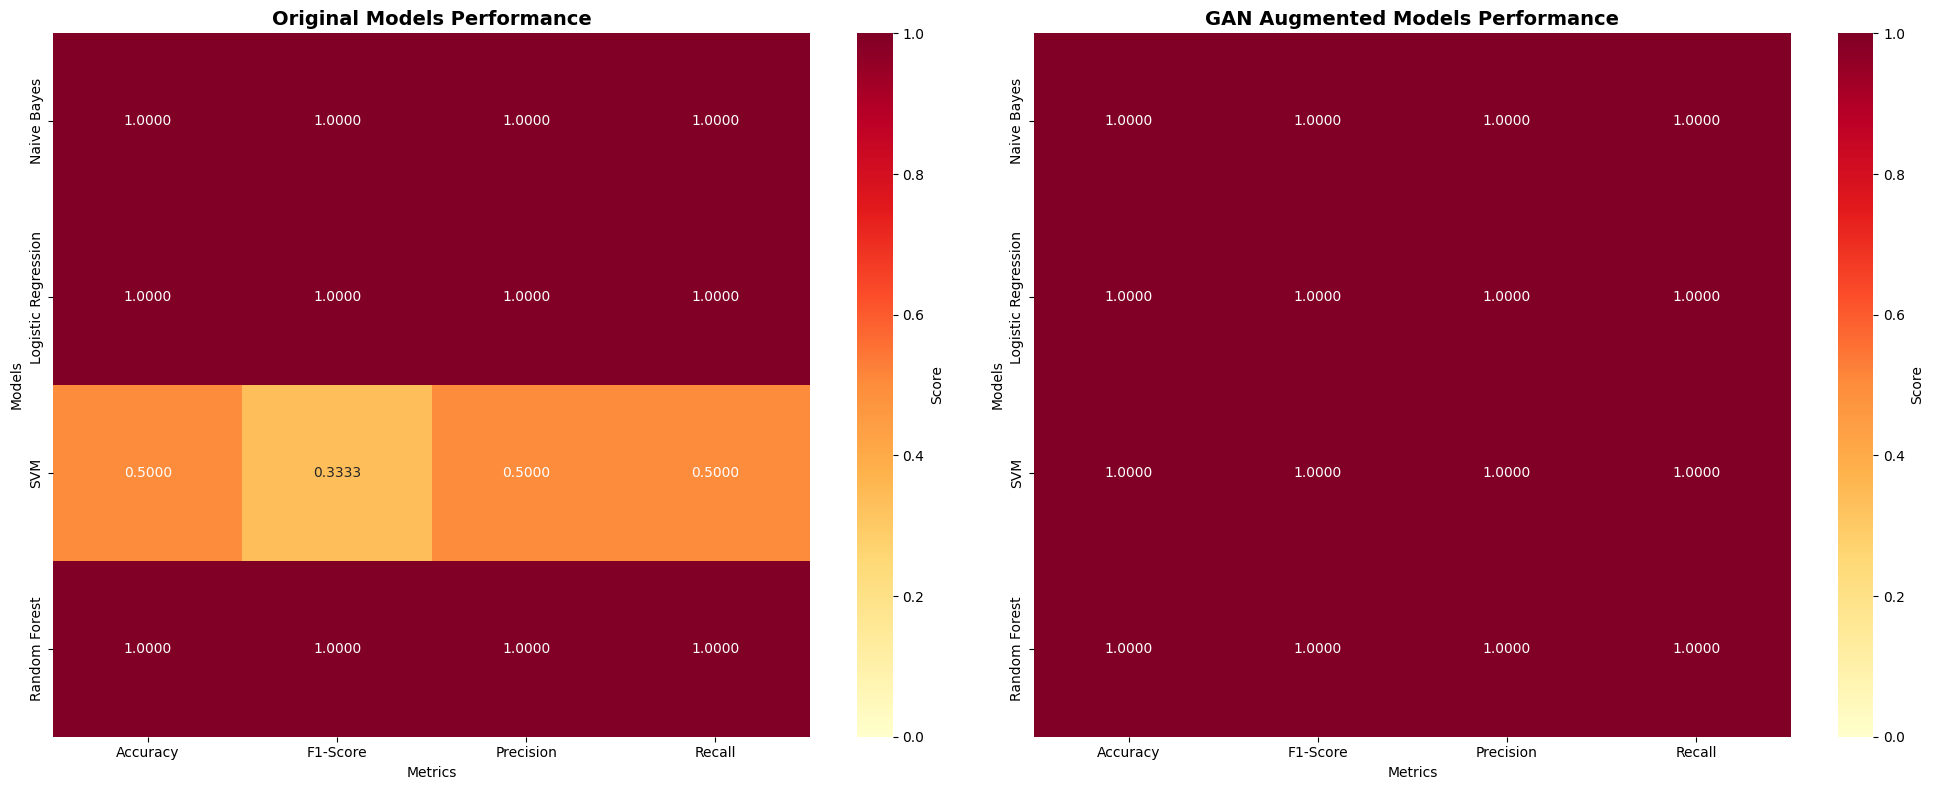

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

original_data = []
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        row.append(max(results_original_gan[model][metric]))
    original_data.append(row)

original_df = pd.DataFrame(original_data, index=models, columns=['Accuracy', 'F1-Score', 'Precision', 'Recall'])

sns.heatmap(
    original_df, 
    annot=True, 
    fmt='.4f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Score'},
    ax=ax1,
    vmin=0,
    vmax=1
)
ax1.set_title('Original Models Performance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Models')

gan_data = []
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        row.append(max(results_gan_augmented[model][metric]))
    gan_data.append(row)

gan_df = pd.DataFrame(gan_data, index=models, columns=['Accuracy', 'F1-Score', 'Precision', 'Recall'])

sns.heatmap(
    gan_df, 
    annot=True, 
    fmt='.4f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Score'},
    ax=ax2,
    vmin=0,
    vmax=1
)
ax2.set_title('GAN Augmented Models Performance', fontsize=14, fontweight='bold')
ax2.set_xlabel('Metrics')
ax2.set_ylabel('Models')

plt.tight_layout()
plt.show()


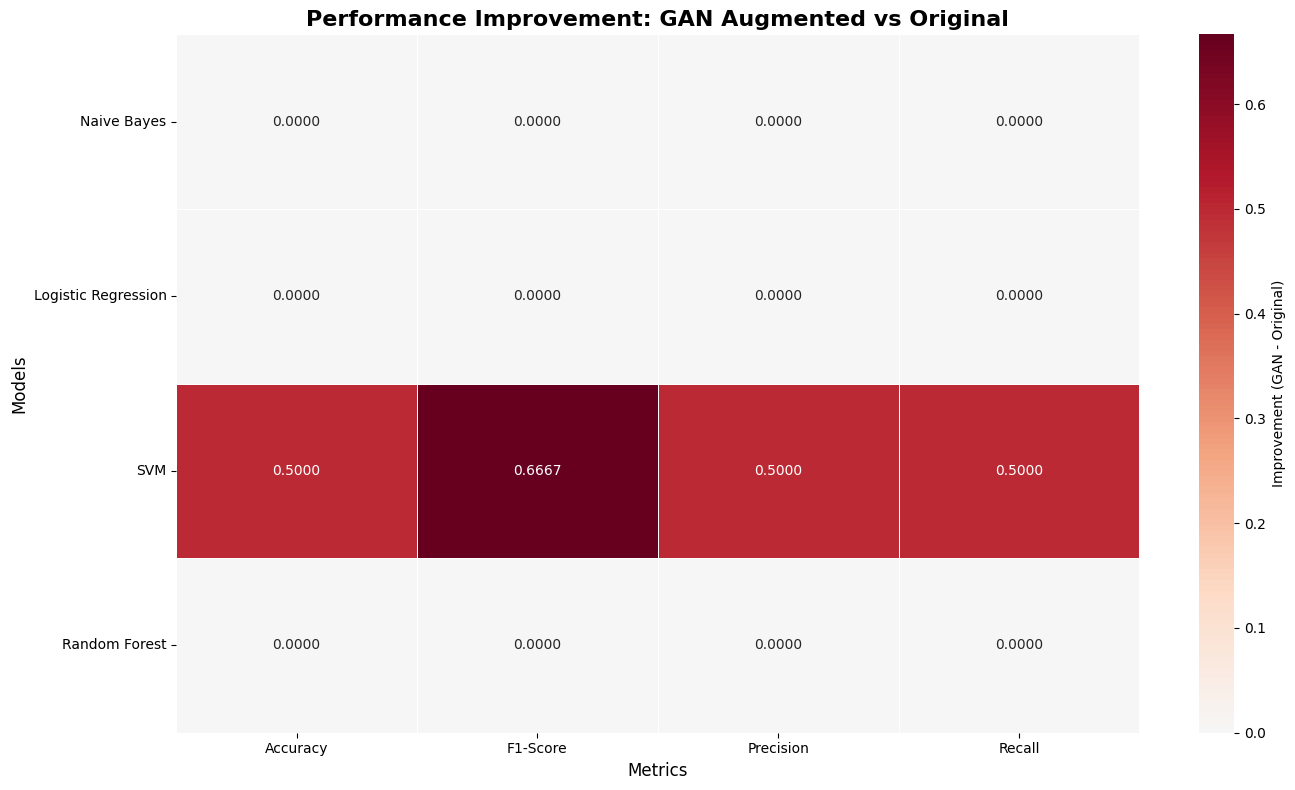

In [96]:
plt.figure(figsize=(14, 8))

difference_data = []
for model in models:
    row = []
    for metric in ['accuracy', 'f1', 'precision', 'recall']:
        original_val = max(results_original_gan[model][metric])
        gan_val = max(results_gan_augmented[model][metric])
        difference = gan_val - original_val
        row.append(difference)
    difference_data.append(row)

difference_df = pd.DataFrame(difference_data, index=models, columns=['Accuracy', 'F1-Score', 'Precision', 'Recall'])

sns.heatmap(
    difference_df, 
    annot=True, 
    fmt='.4f', 
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Improvement (GAN - Original)'},
    linewidths=0.5
)

plt.title('Performance Improvement: GAN Augmented vs Original', fontsize=16, fontweight='bold')
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()